# Questao 1

Projeto manual de filtros FIR por janelamento para `f_s = 20000 Hz`, ordens
`M in {20, 50, 100}` e janelas retangular, triangular, Bartlett, Hamming,
Hann e Blackman.

A resposta ideal de cada filtro e obtida analiticamente e truncada para
`M + 1` amostras. Em seguida, os coeficientes sao multiplicados pela janela
escolhida, sem usar nenhuma funcao pronta de projeto de filtro.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()
for candidate in [CWD, *CWD.parents]:
    helper_path = candidate / 'pratica_7' / 'fir_utils.py'
    if helper_path.exists():
        REPO_ROOT = candidate
        break
else:
    raise FileNotFoundError('Nao foi possivel localizar pratica_7/fir_utils.py a partir do diretorio atual.')

PRACTICE_DIR = REPO_ROOT / 'pratica_7'
DATA_DIR = REPO_ROOT / 'data'
if str(PRACTICE_DIR) not in sys.path:
    sys.path.insert(0, str(PRACTICE_DIR))

from fir_utils import (
    WINDOW_BUILDERS,
    apply_window,
    display_rows,
    ideal_bandpass,
    ideal_bandstop,
    ideal_highpass,
    ideal_lowpass,
    plot_frequency_grid,
    plot_impulse_grid,
    plot_pole_zero_grid,
    summarize_error_bank,
)

FS = 20000.0
ORDERS = [20, 50, 100]
WINDOWS = ['retangular', 'triangular', 'bartlett', 'hamming', 'hann', 'blackman']


As quatro respostas ideais usadas aqui sao:

- passa-baixas: `h_d[n] = (w_c / pi)` em `n = M/2` e `sin(w_c (n - M/2)) / (pi (n - M/2))` nos demais pontos;
- passa-altas: `delta[n - M/2] - h_lp[n]`;
- passa-faixas: `h_lp(fc2) - h_lp(fc1)`;
- rejeita-faixas: `delta[n - M/2] - h_bp[n]`.

O objetivo do notebook e comparar a influencia simultanea da ordem e da
janela sobre a aproximacao do filtro ideal.


1(a) Passa-baixas, fc = 1000 Hz


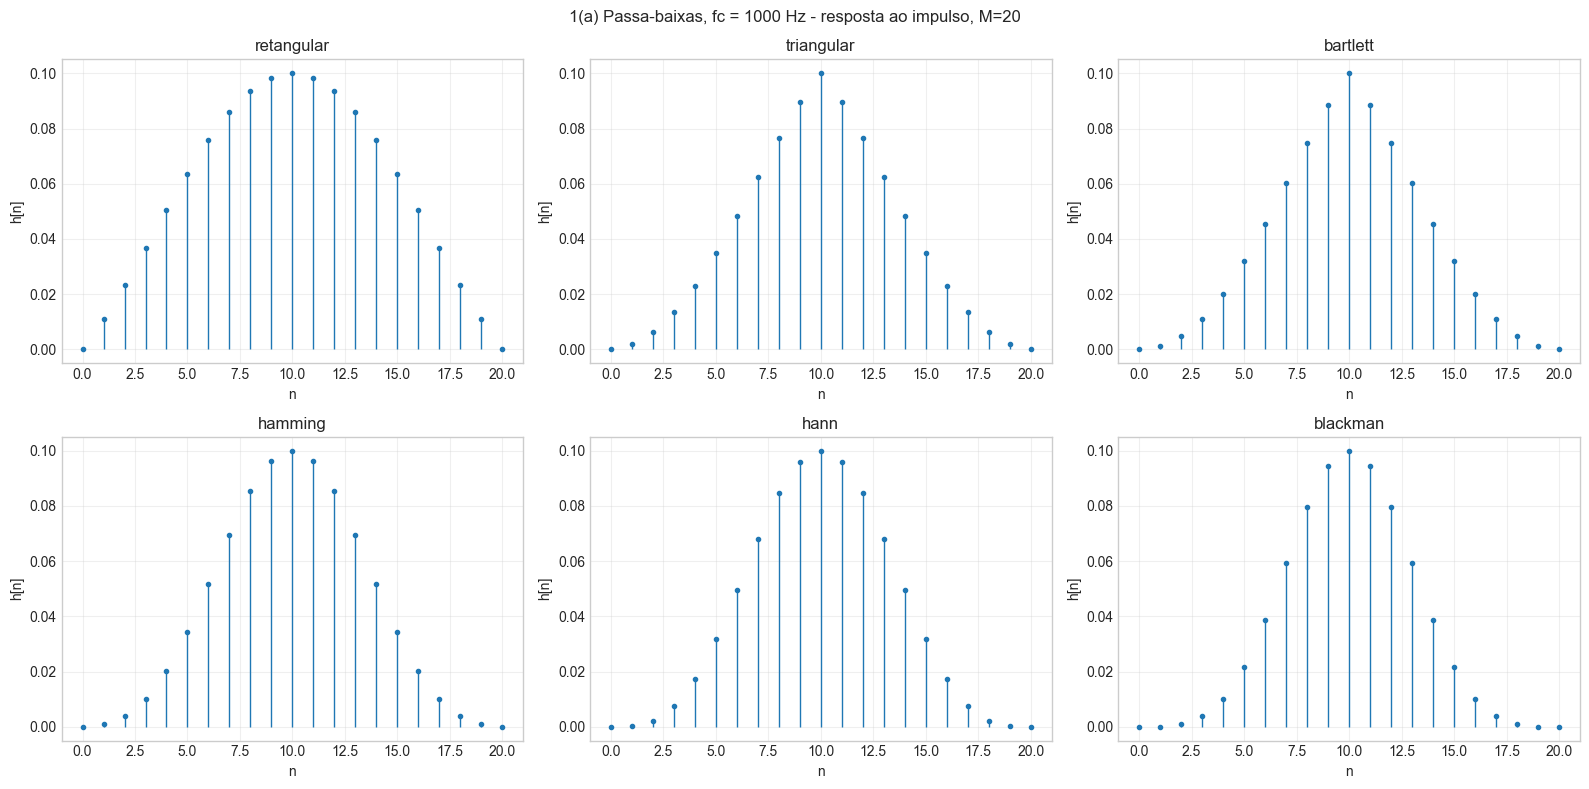

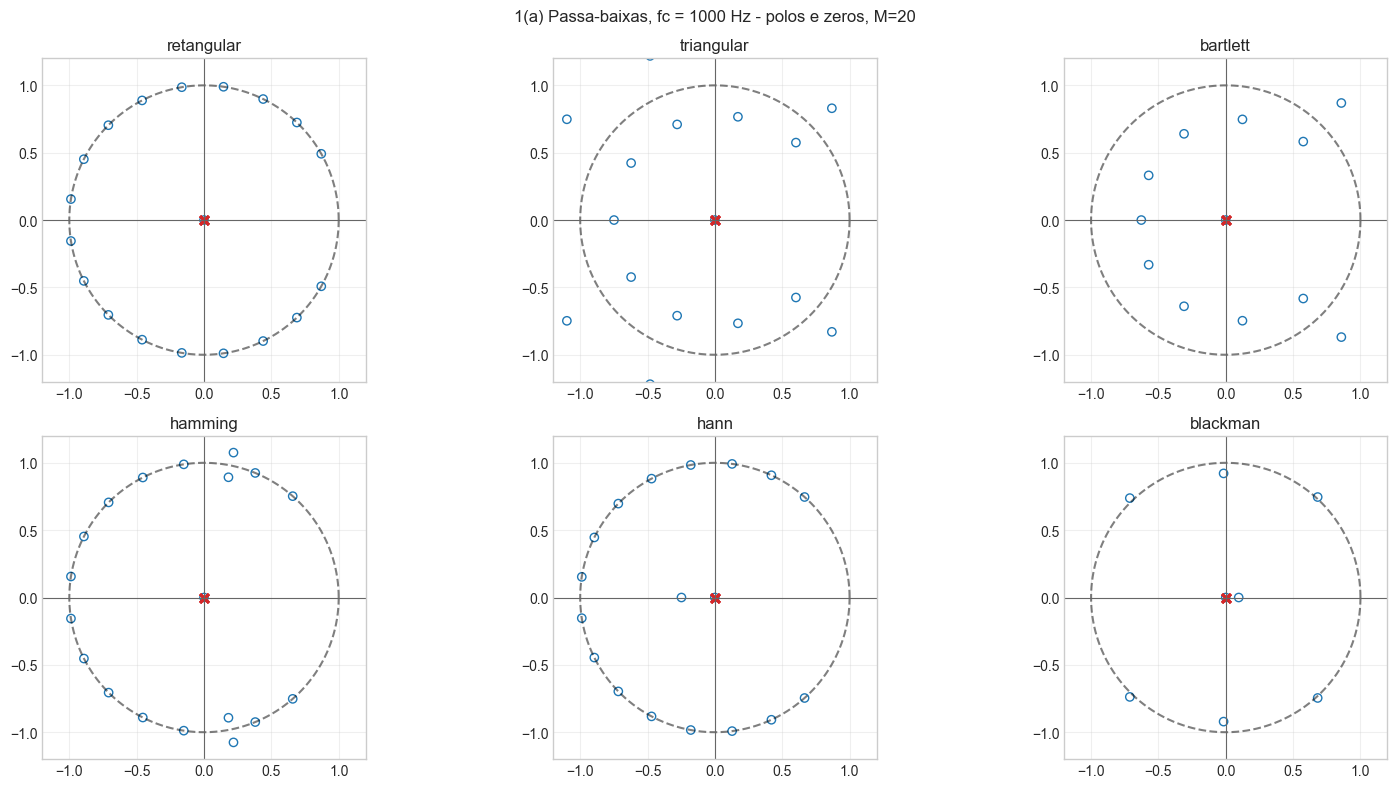

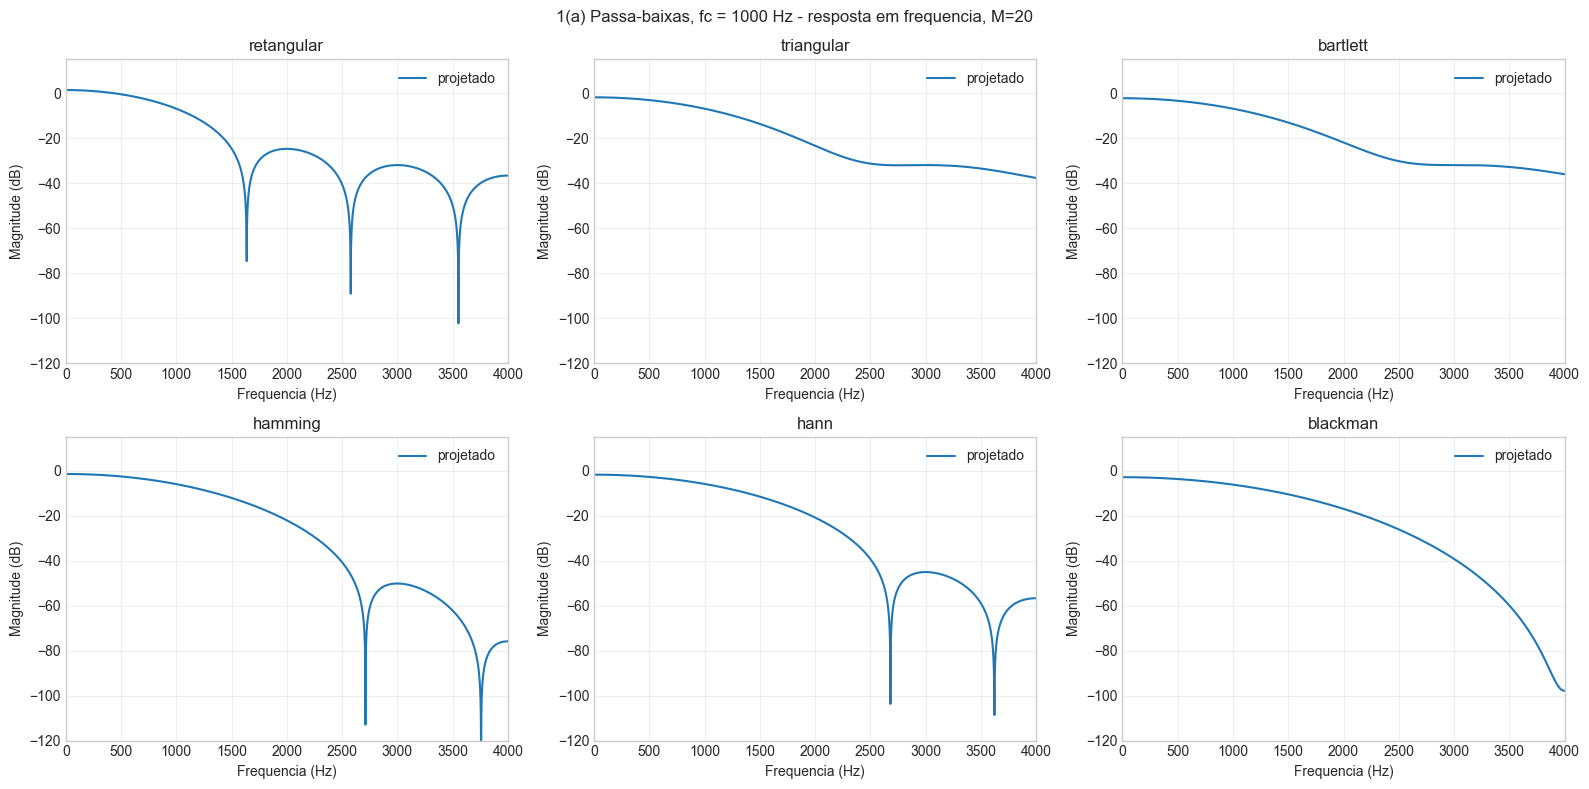

Erros de aproximacao para M=20:
Filtro     | Erro RMS | Erro max | Ganho max
-----------+----------+----------+----------
retangular | 0.098604 | 0.546668 | 1.177312 
triangular | 0.134524 | 0.546779 | 0.811907 
bartlett   | 0.140911 | 0.546790 | 0.775366 
hamming    | 0.132310 | 0.501559 | 0.844169 
hann       | 0.137548 | 0.505859 | 0.815200 
blackman   | 0.156650 | 0.510671 | 0.716367 



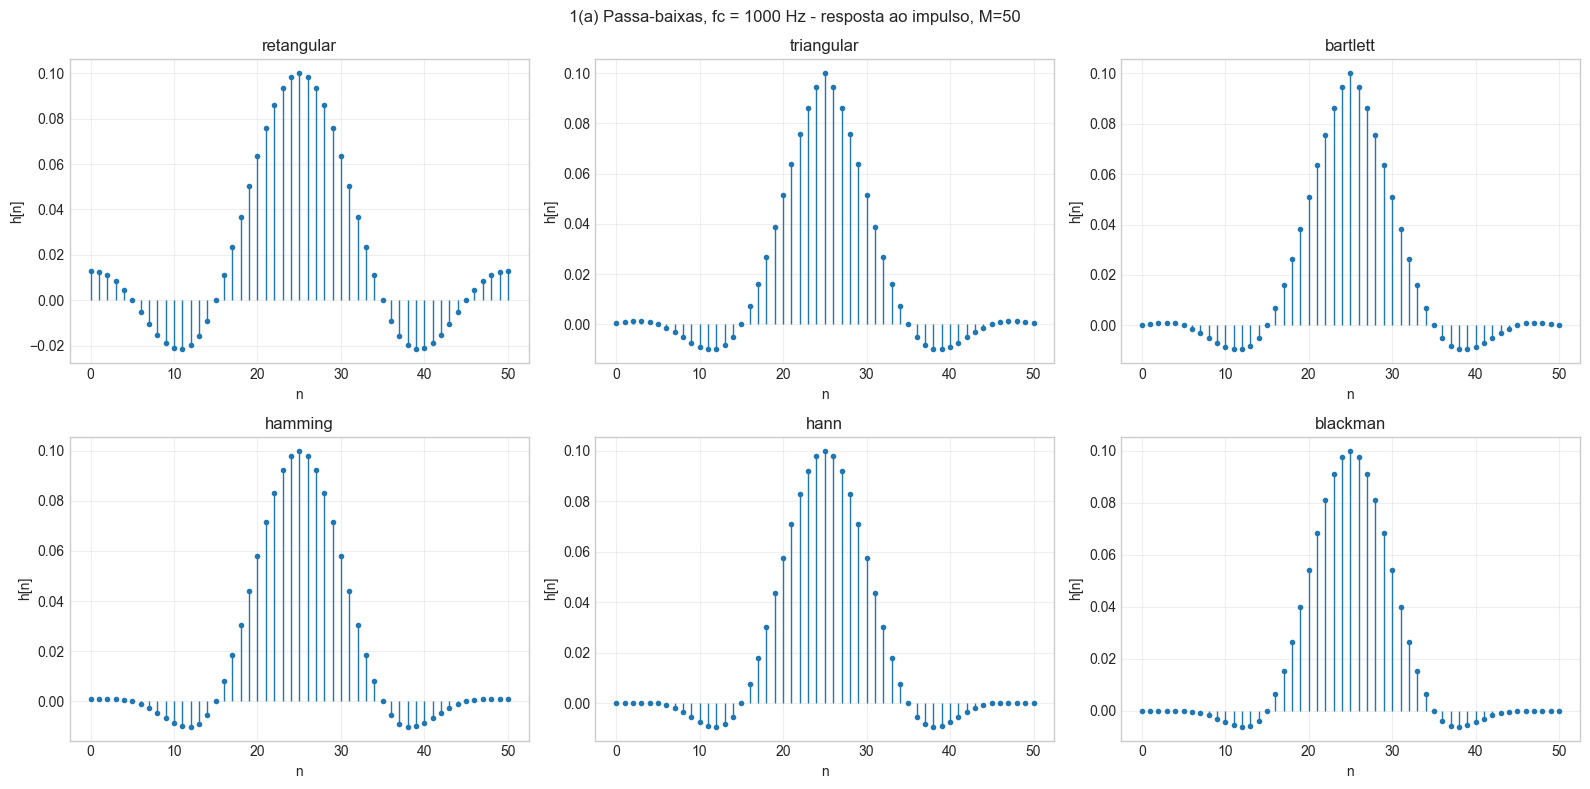

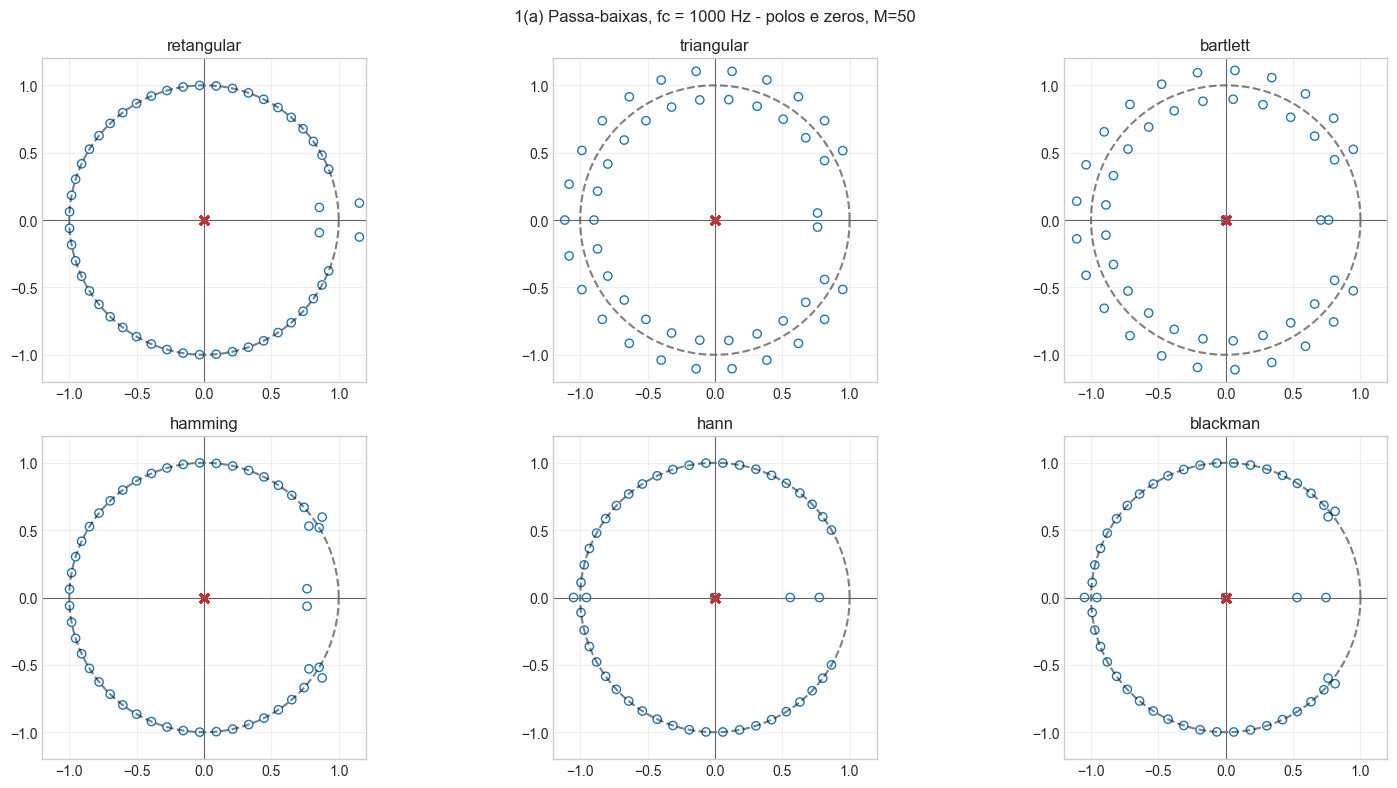

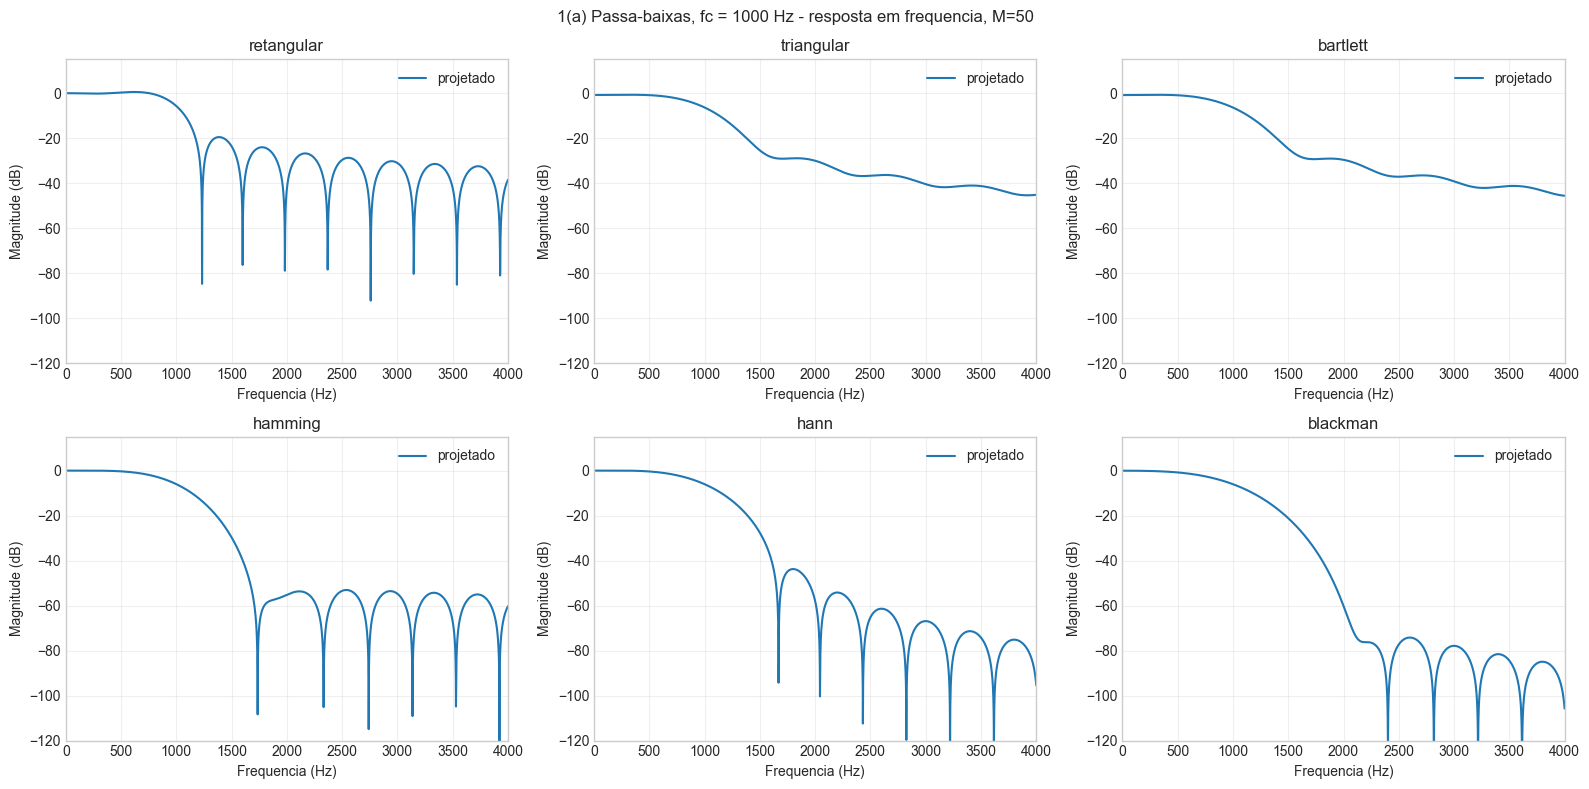

Erros de aproximacao para M=50:
Filtro     | Erro RMS | Erro max | Ganho max
-----------+----------+----------+----------
retangular | 0.062633 | 0.516897 | 1.065867 
triangular | 0.088448 | 0.517930 | 0.924469 
bartlett   | 0.090229 | 0.519450 | 0.922053 
hamming    | 0.082204 | 0.499858 | 1.003020 
hann       | 0.085274 | 0.500097 | 1.004494 
blackman   | 0.093633 | 0.499854 | 0.998021 



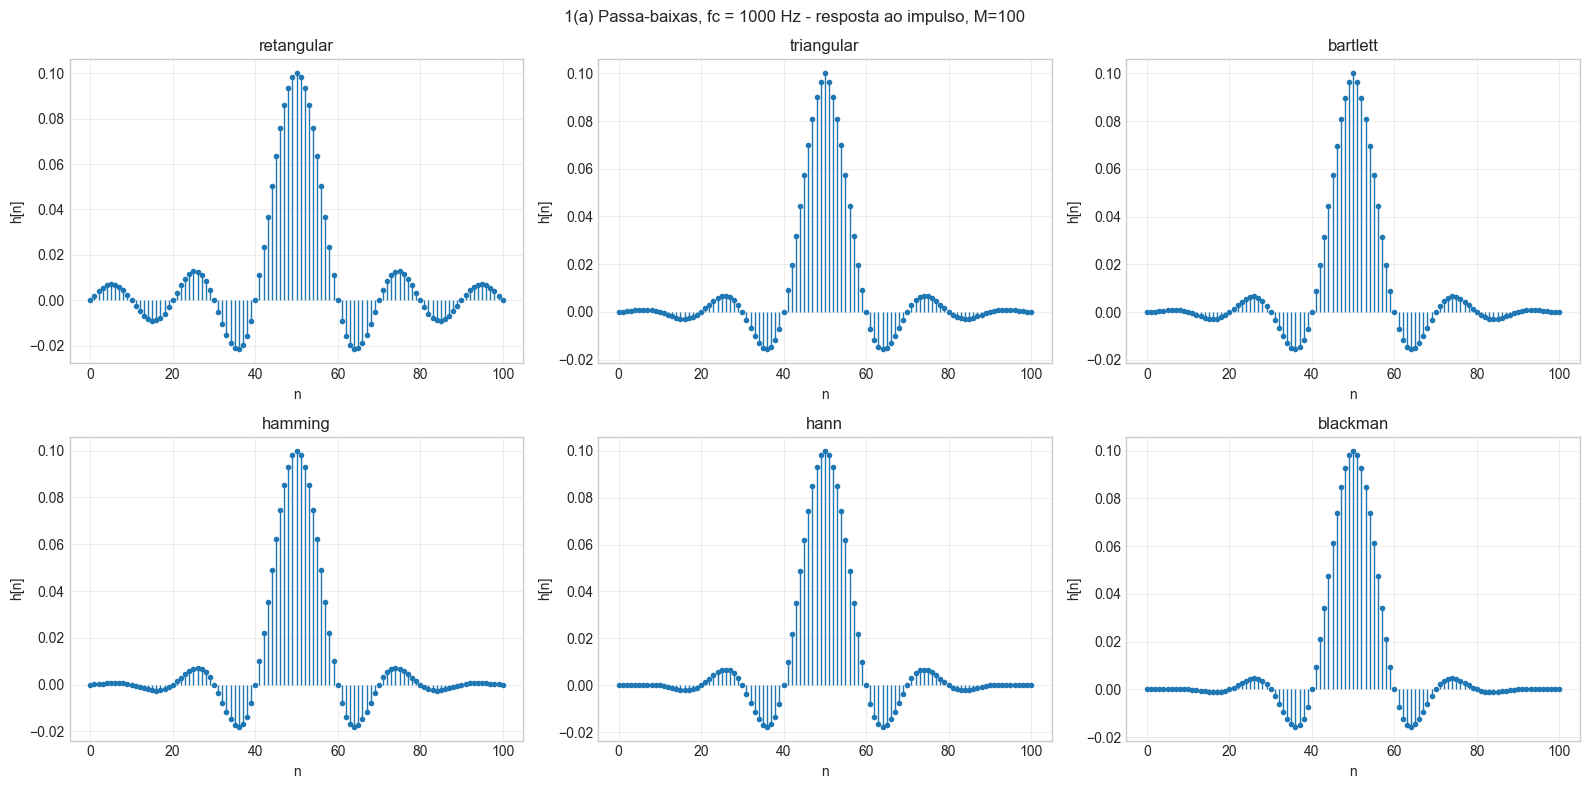

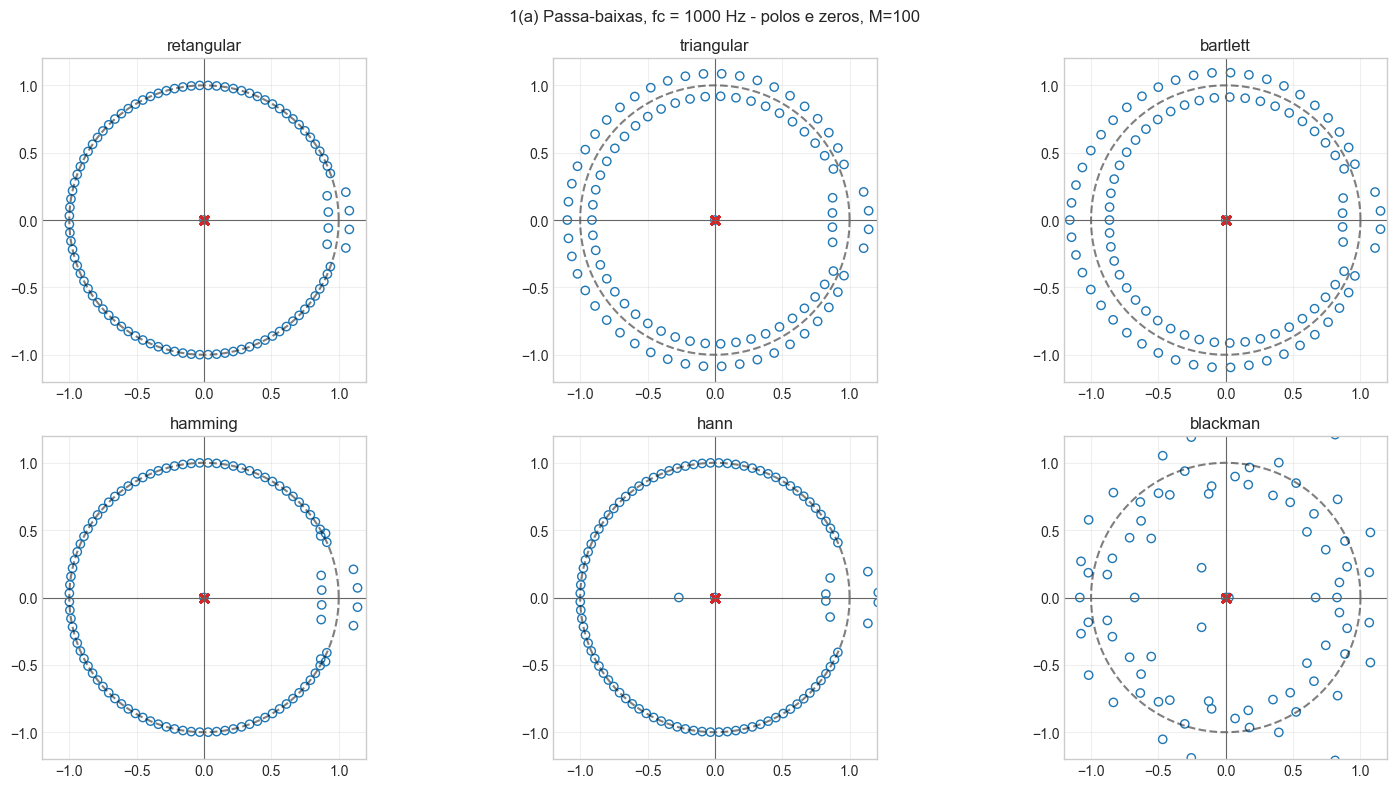

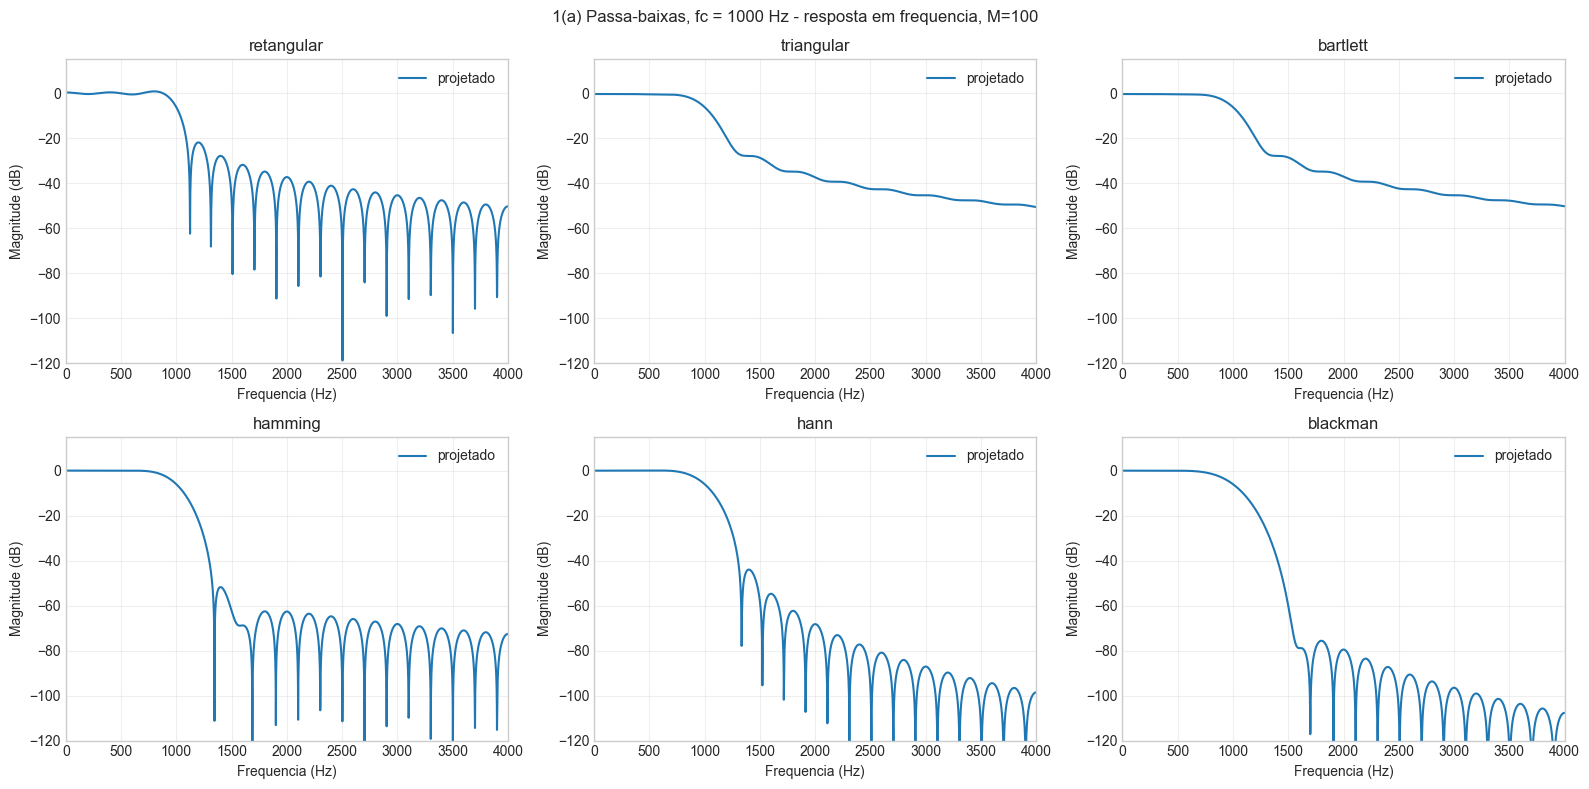

Erros de aproximacao para M=100:
Filtro     | Erro RMS | Erro max | Ganho max
-----------+----------+----------+----------
retangular | 0.044980 | 0.508556 | 1.100382 
triangular | 0.063015 | 0.509154 | 0.961068 
bartlett   | 0.063637 | 0.509166 | 0.959491 
hamming    | 0.058223 | 0.500076 | 1.002450 
hann       | 0.060316 | 0.499339 | 1.006450 
blackman   | 0.066213 | 0.499470 | 1.000243 

1(b) Passa-altas, fc = 2000 Hz


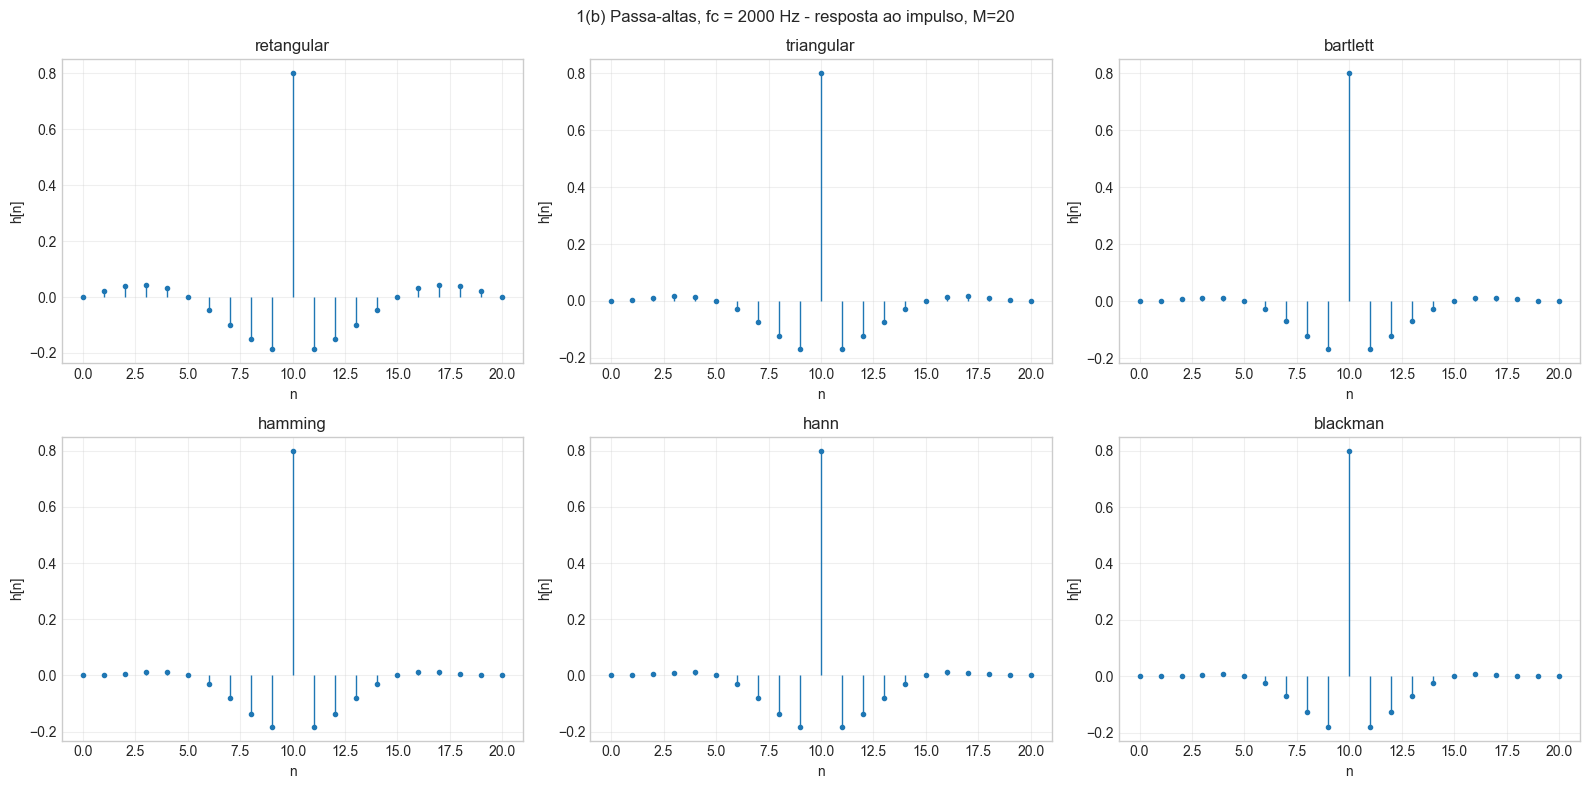

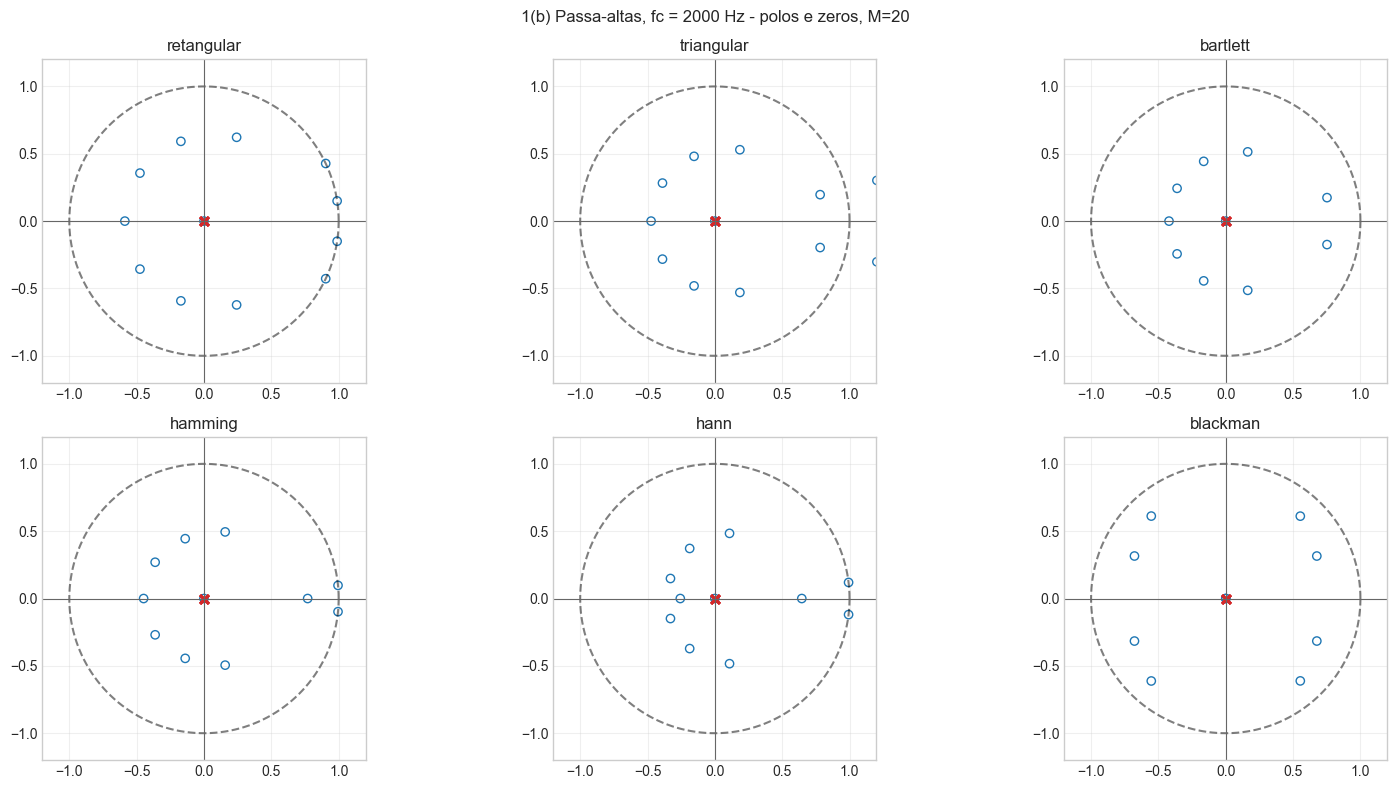

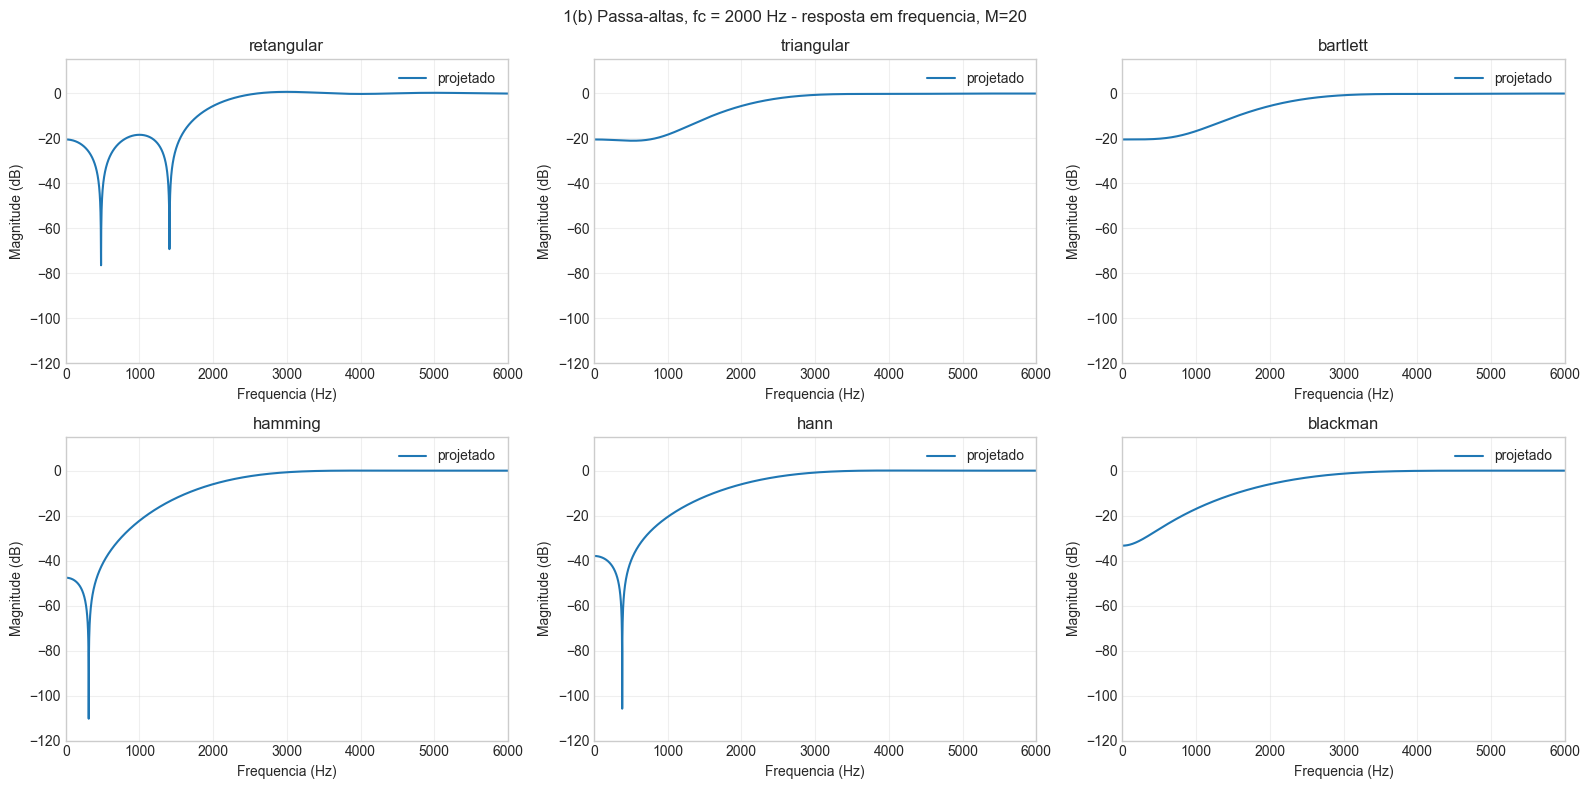

Erros de aproximacao para M=20:
Filtro     | Erro RMS | Erro max | Ganho max
-----------+----------+----------+----------
retangular | 0.100059 | 0.521121 | 1.072892 
triangular | 0.135593 | 0.521343 | 0.991293 
bartlett   | 0.141929 | 0.521365 | 0.989713 
hamming    | 0.130208 | 0.500752 | 1.002805 
hann       | 0.134960 | 0.500409 | 1.006131 
blackman   | 0.148094 | 0.499861 | 1.000146 



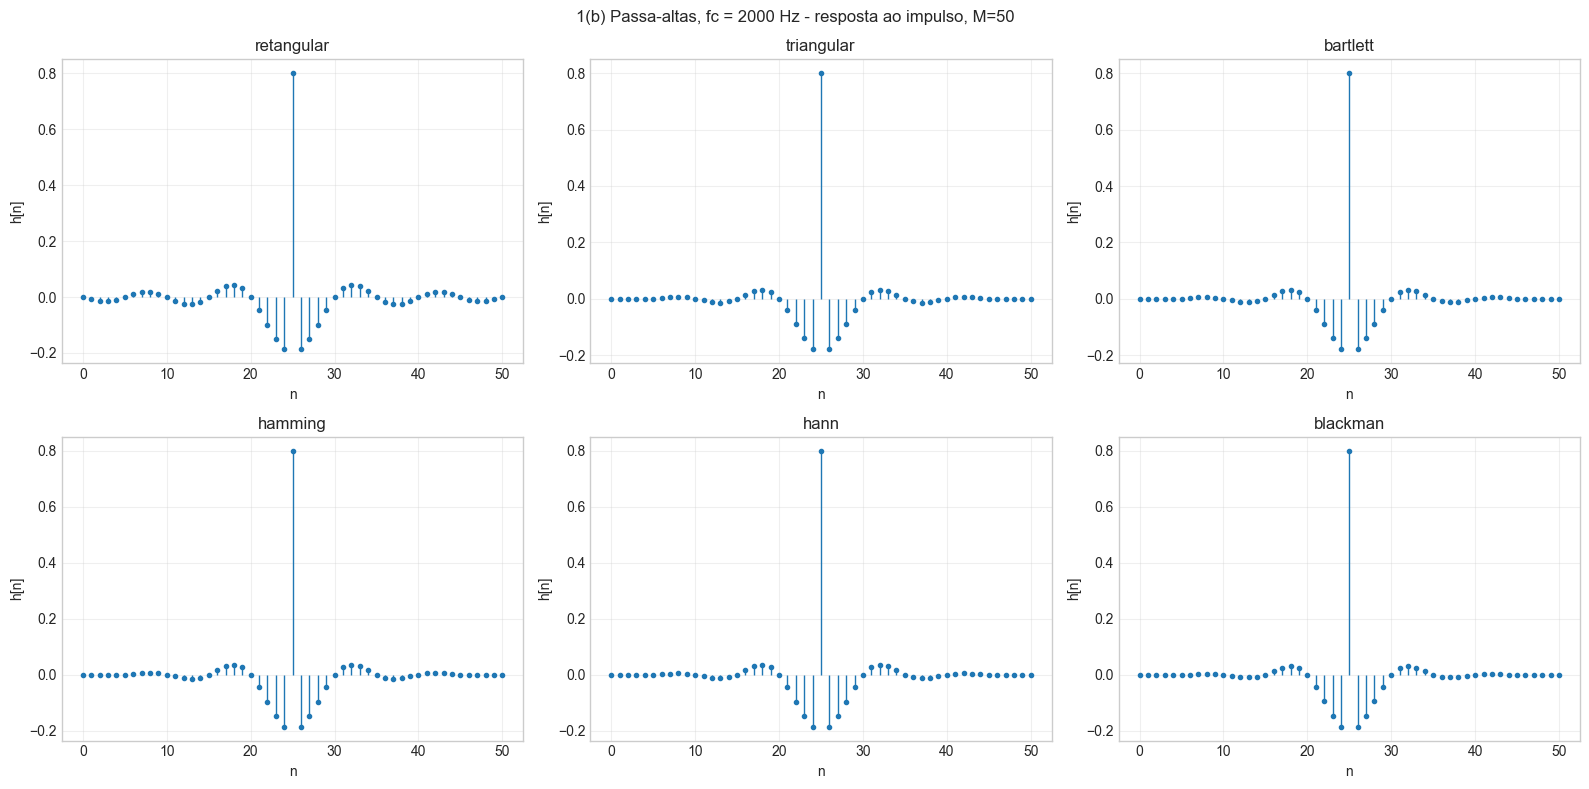

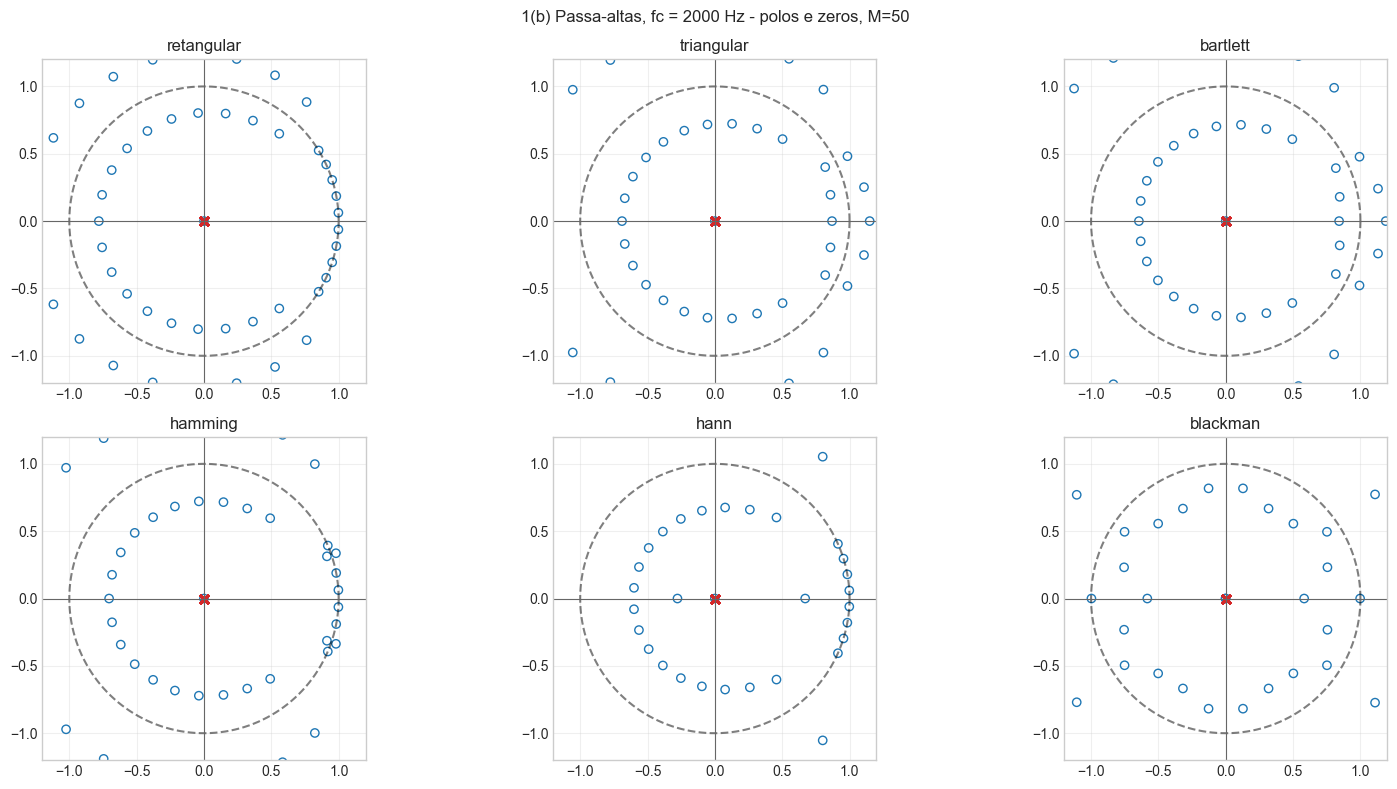

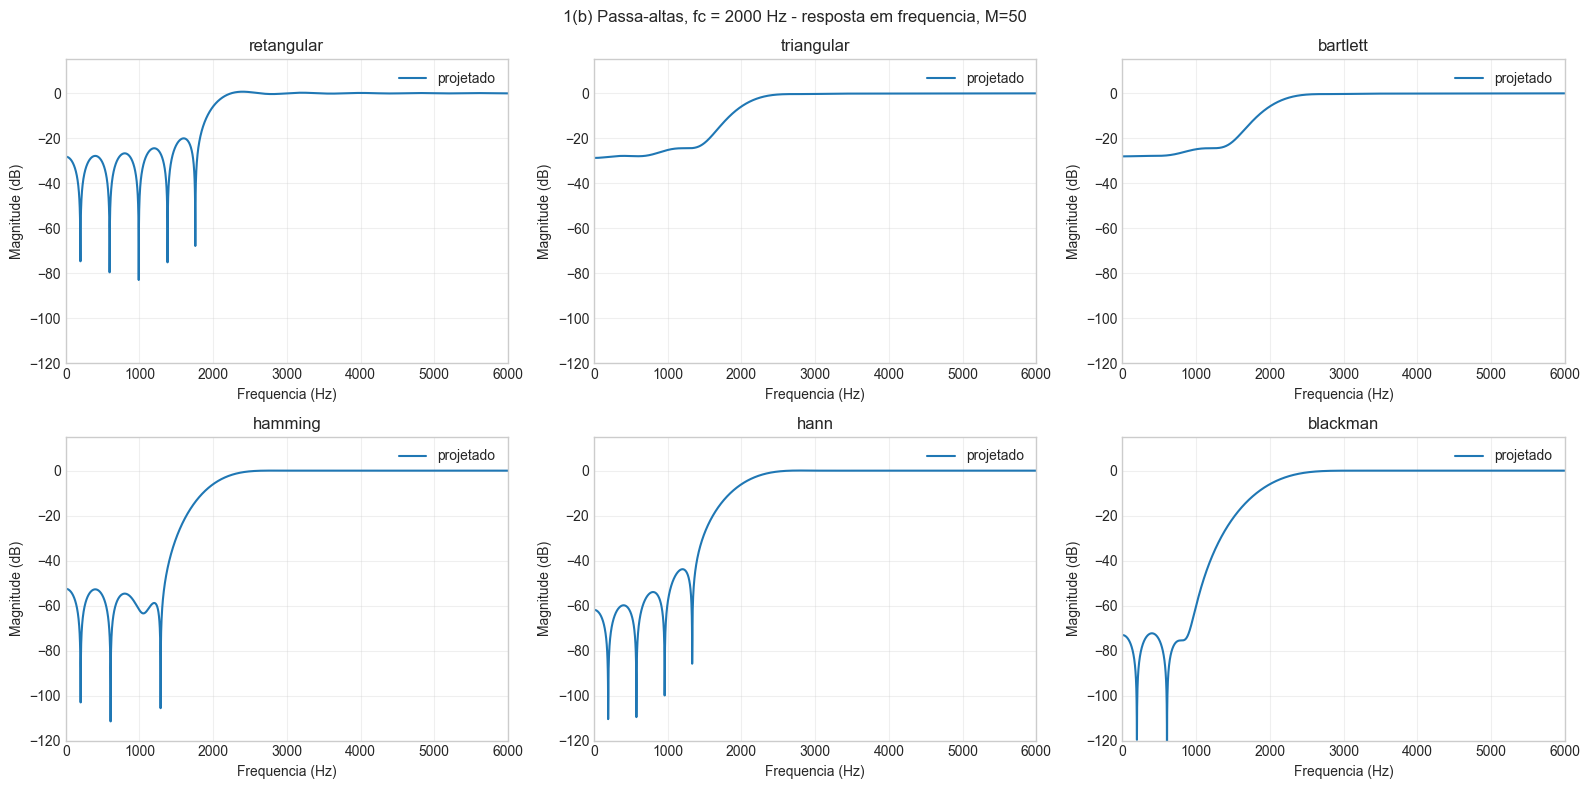

Erros de aproximacao para M=50:
Filtro     | Erro RMS | Erro max | Ganho max
-----------+----------+----------+----------
retangular | 0.063600 | 0.507522 | 1.081676 
triangular | 0.088272 | 0.508108 | 0.996162 
bartlett   | 0.089988 | 0.508132 | 0.995867 
hamming    | 0.082338 | 0.499994 | 1.002493 
hann       | 0.085299 | 0.499340 | 1.006323 
blackman   | 0.093639 | 0.499470 | 1.000166 



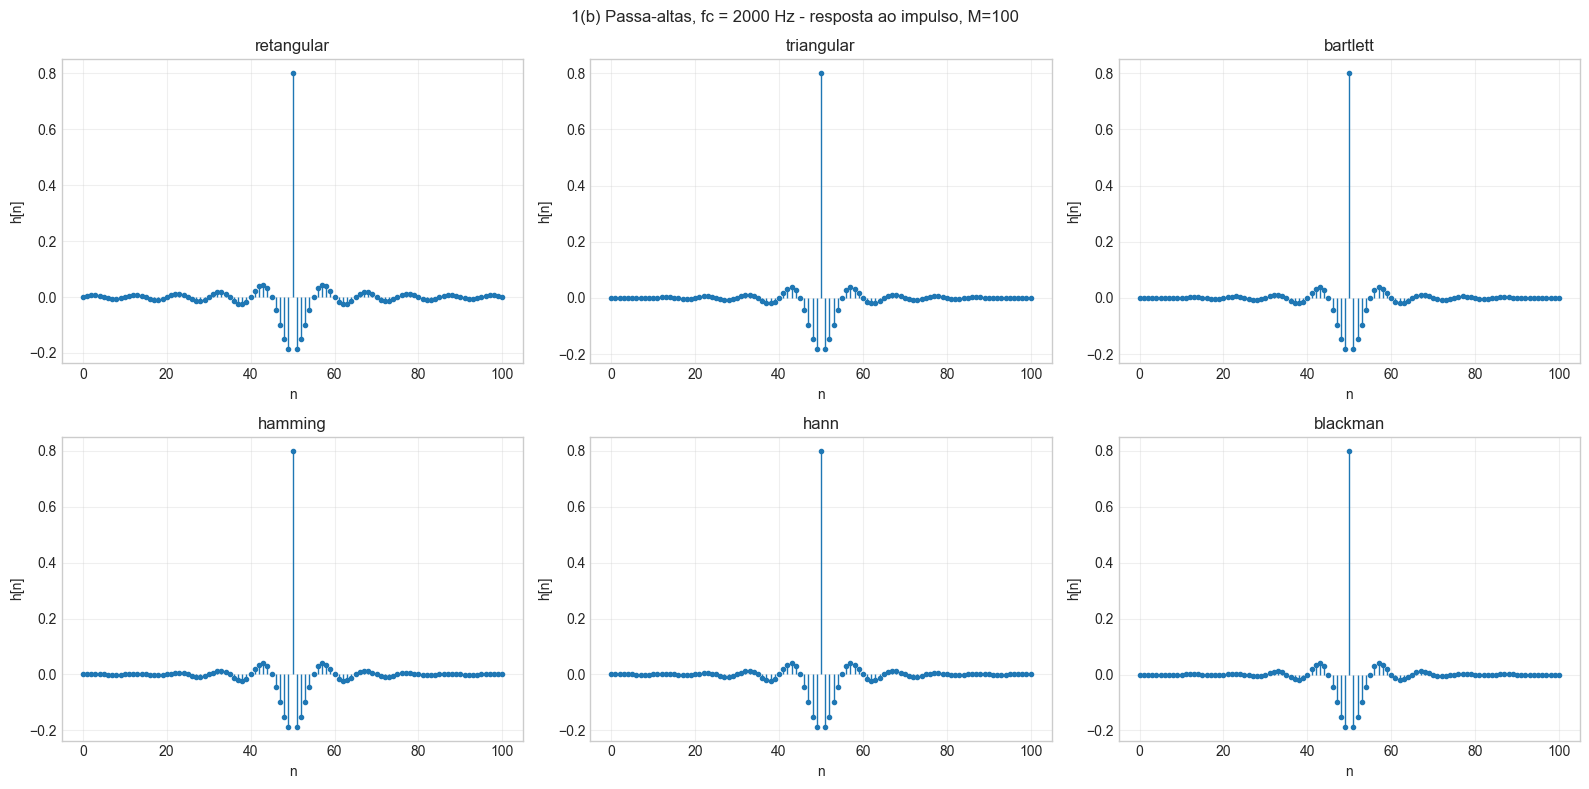

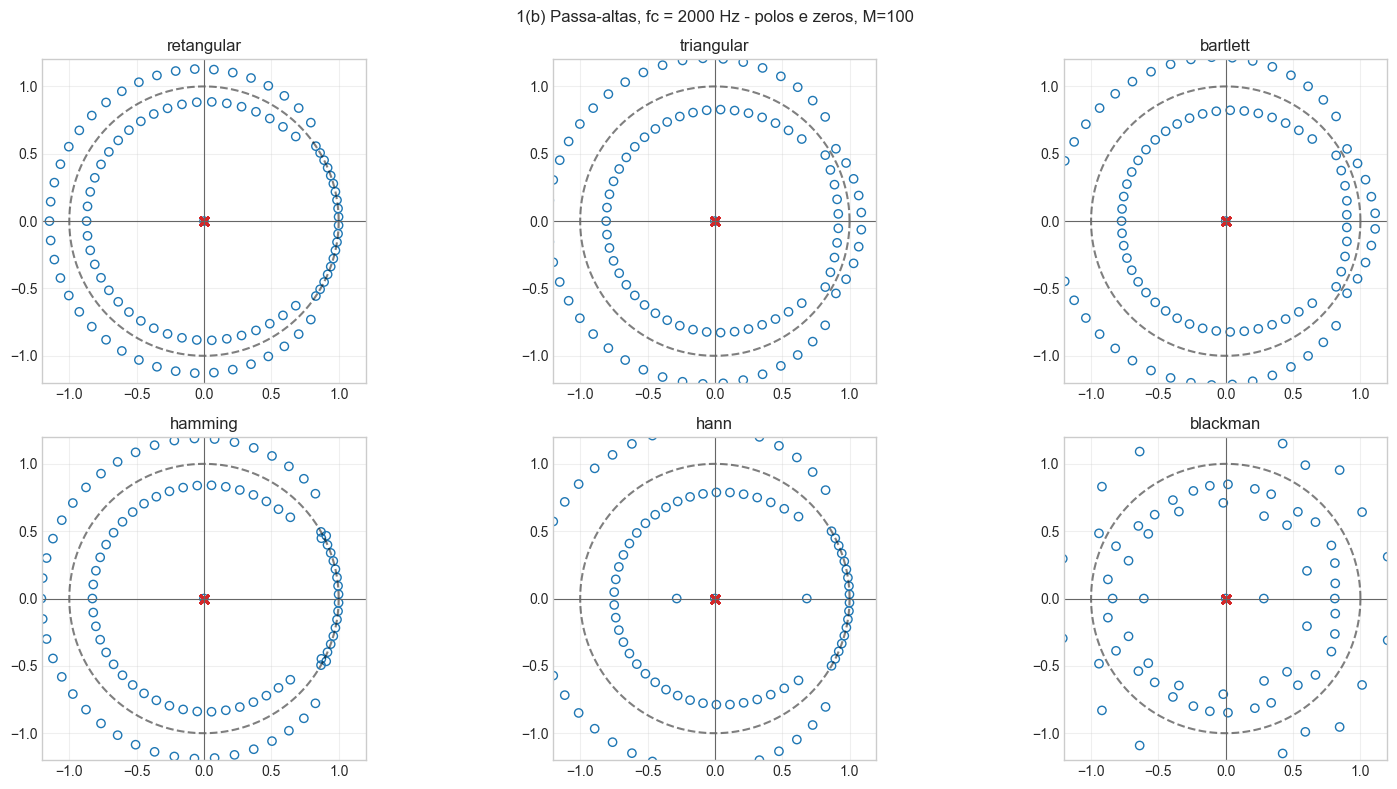

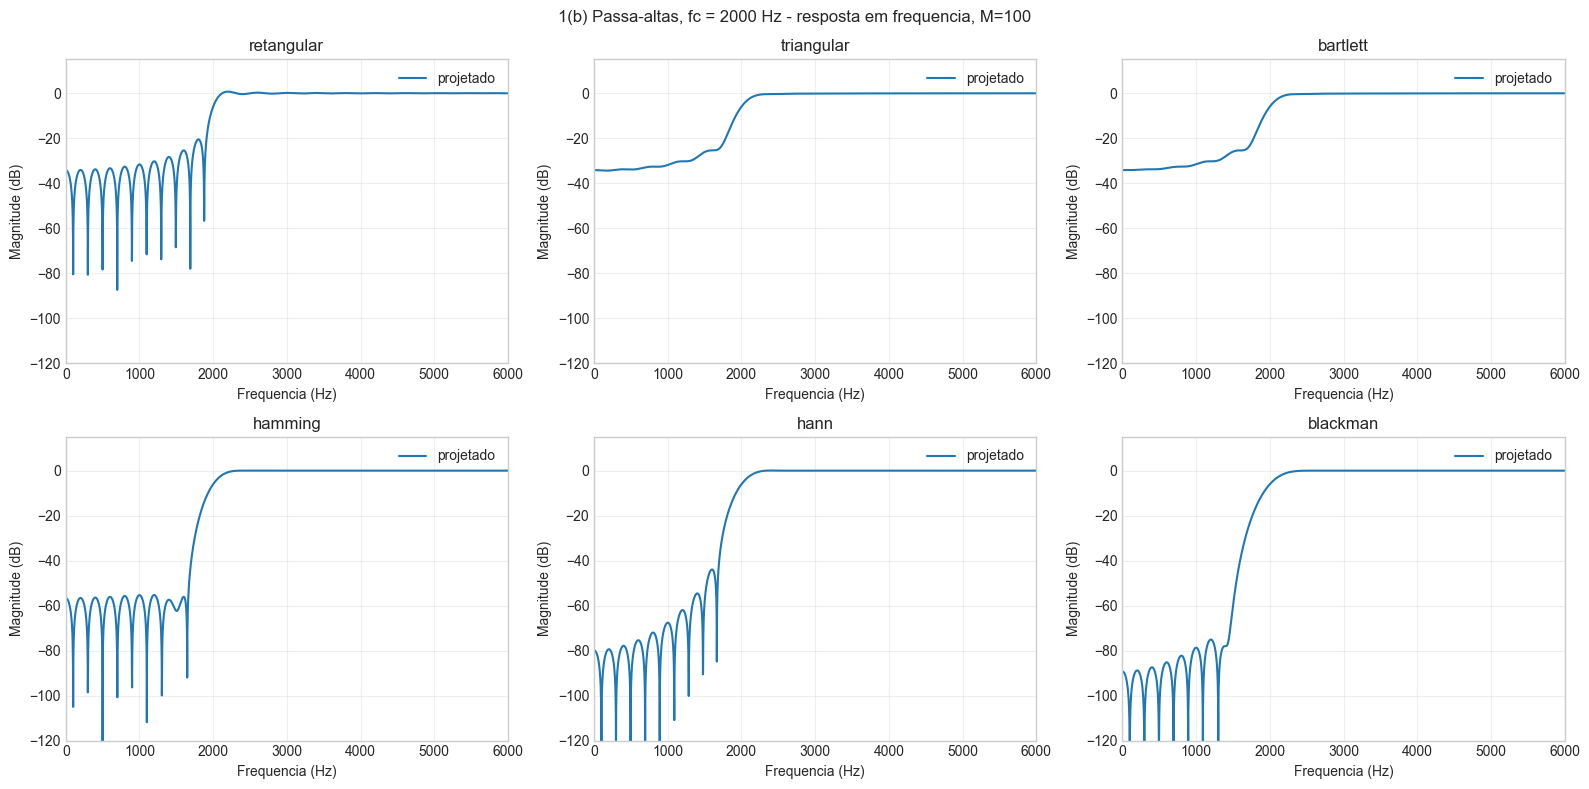

Erros de aproximacao para M=100:
Filtro     | Erro RMS | Erro max | Ganho max
-----------+----------+----------+----------
retangular | 0.045005 | 0.501937 | 1.085354 
triangular | 0.063034 | 0.503134 | 0.998010 
bartlett   | 0.063655 | 0.503158 | 0.997932 
hamming    | 0.058225 | 0.499026 | 1.002265 
hann       | 0.060314 | 0.498773 | 1.006347 
blackman   | 0.066212 | 0.498972 | 1.000171 

1(c) Passa-faixas, fc1 = 500 Hz e fc2 = 2000 Hz


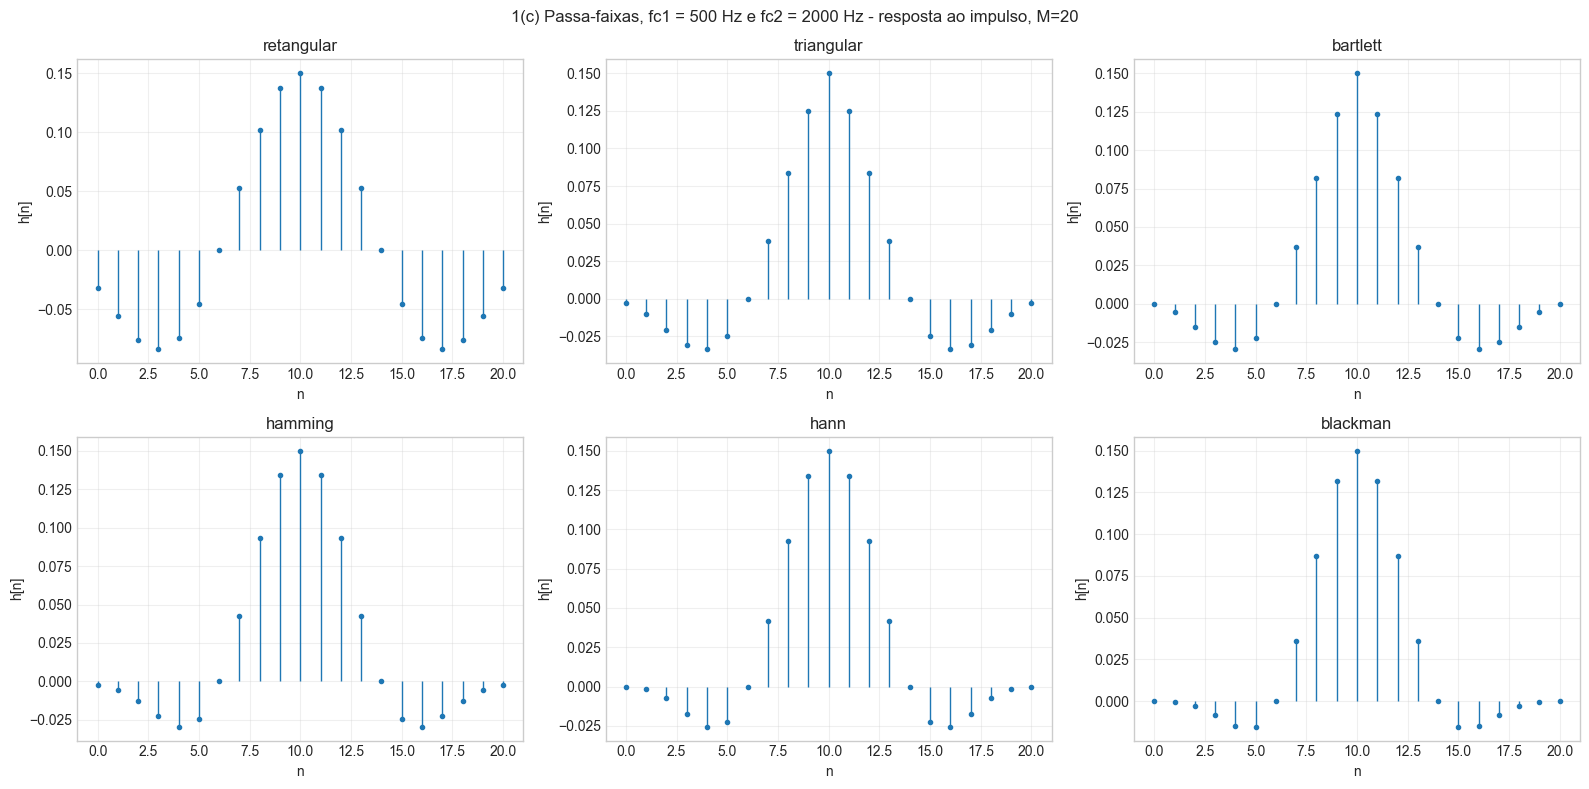

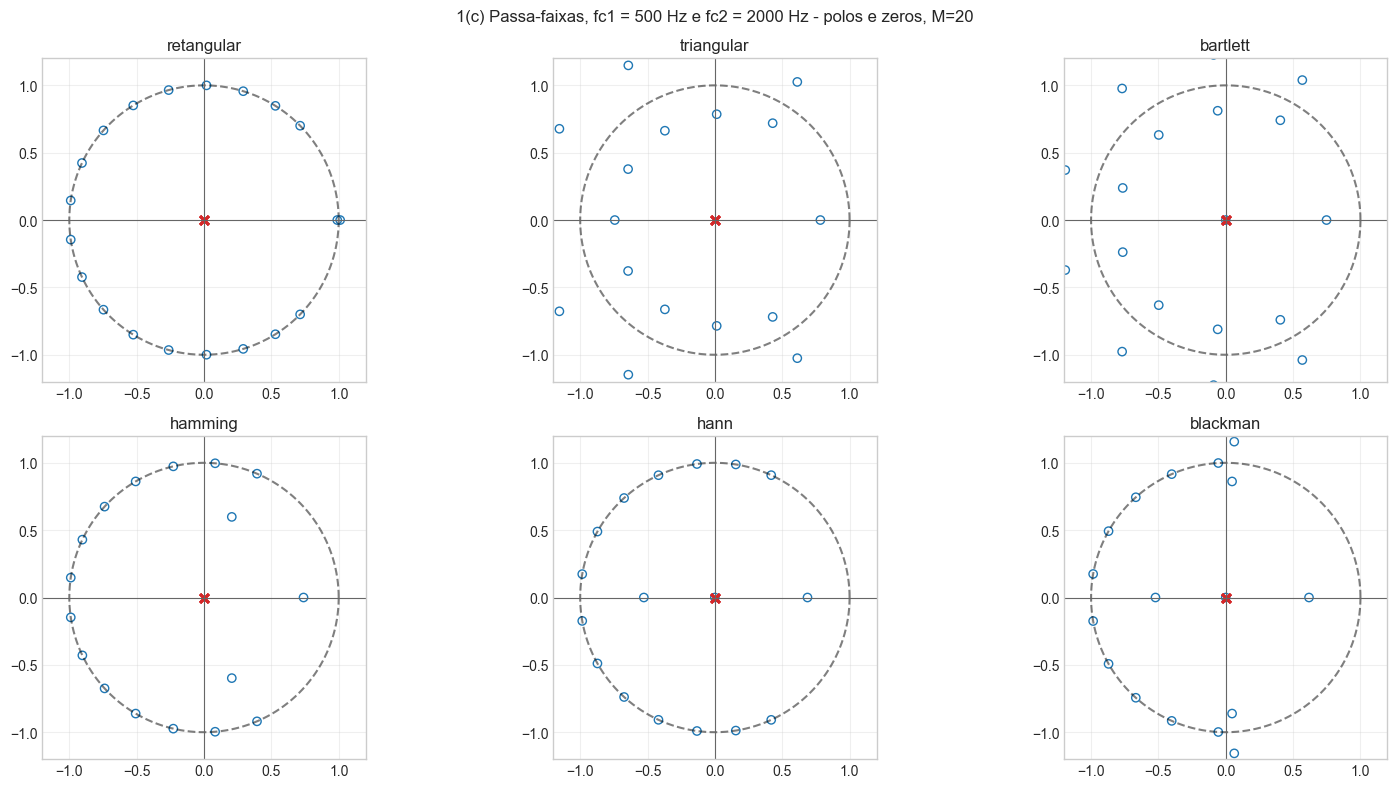

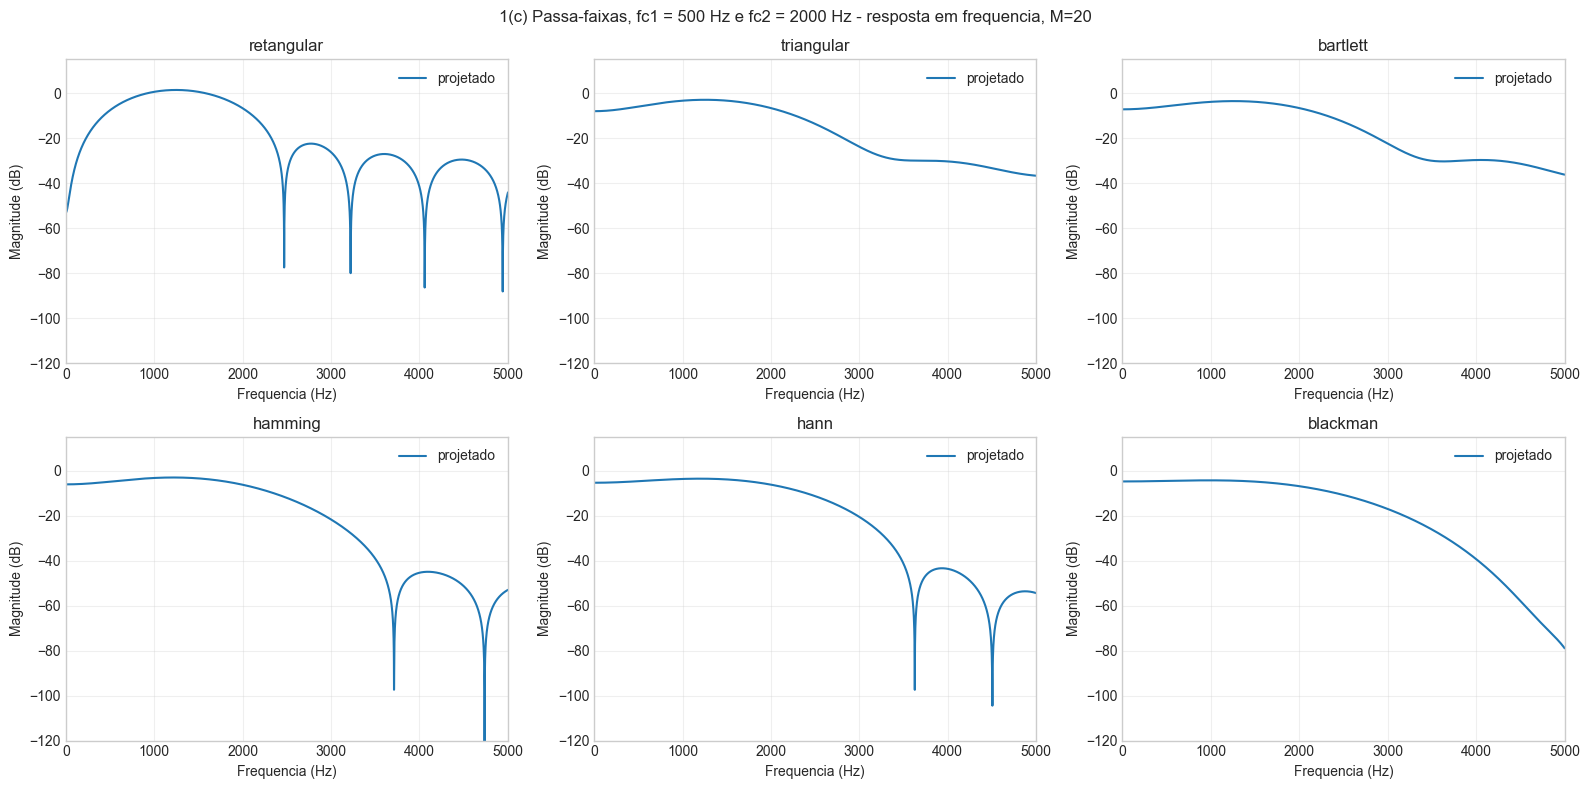

Erros de aproximacao para M=20:
Filtro     | Erro RMS | Erro max | Ganho max
-----------+----------+----------+----------
retangular | 0.120799 | 0.580766 | 1.181955 
triangular | 0.194150 | 0.532305 | 0.715055 
bartlett   | 0.206266 | 0.531983 | 0.668384 
hamming    | 0.204838 | 0.569205 | 0.704545 
hann       | 0.216623 | 0.582398 | 0.663270 
blackman   | 0.233384 | 0.591351 | 0.609027 



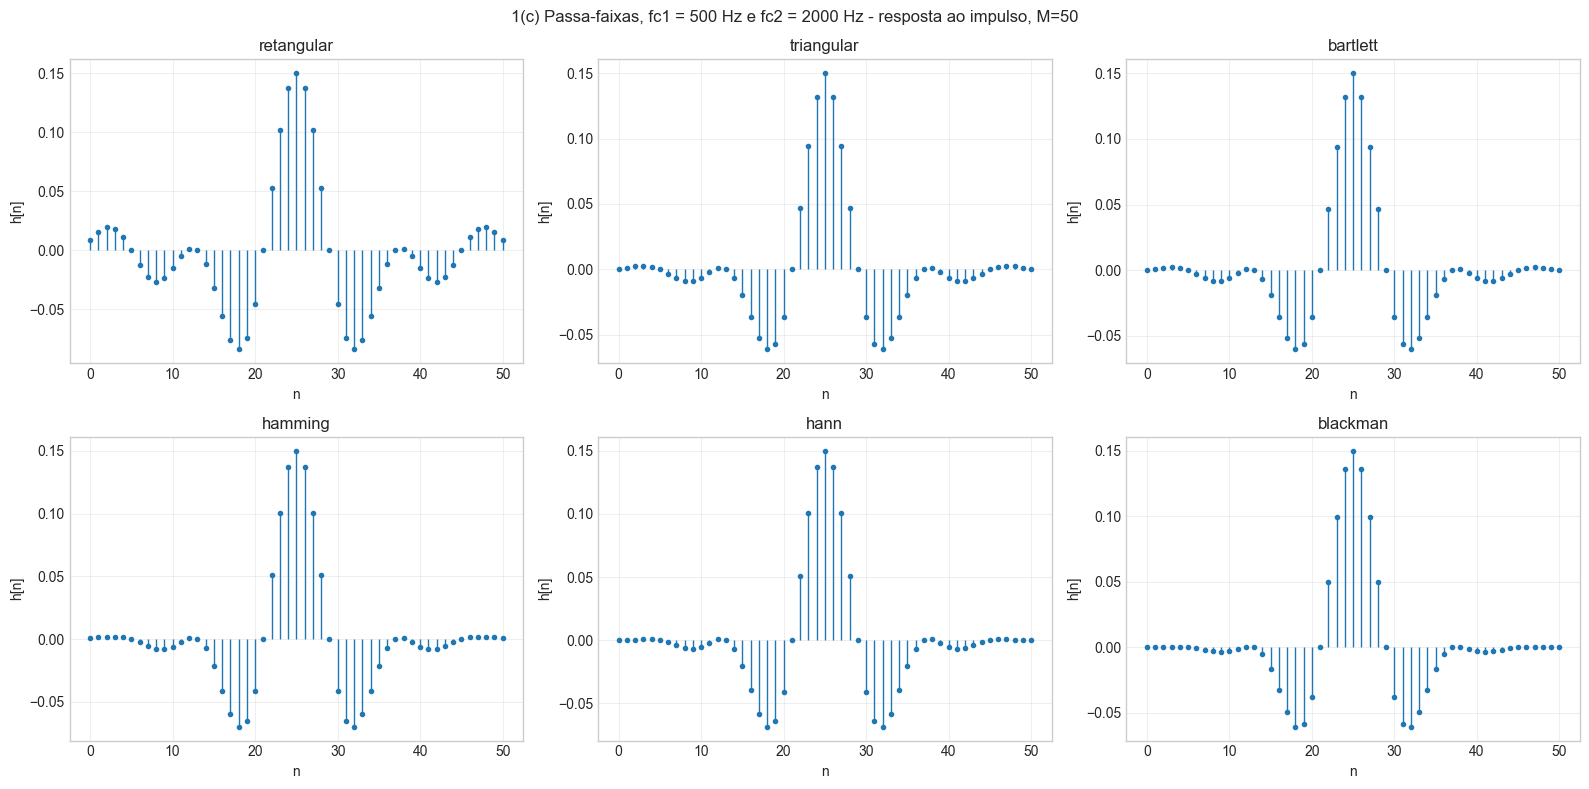

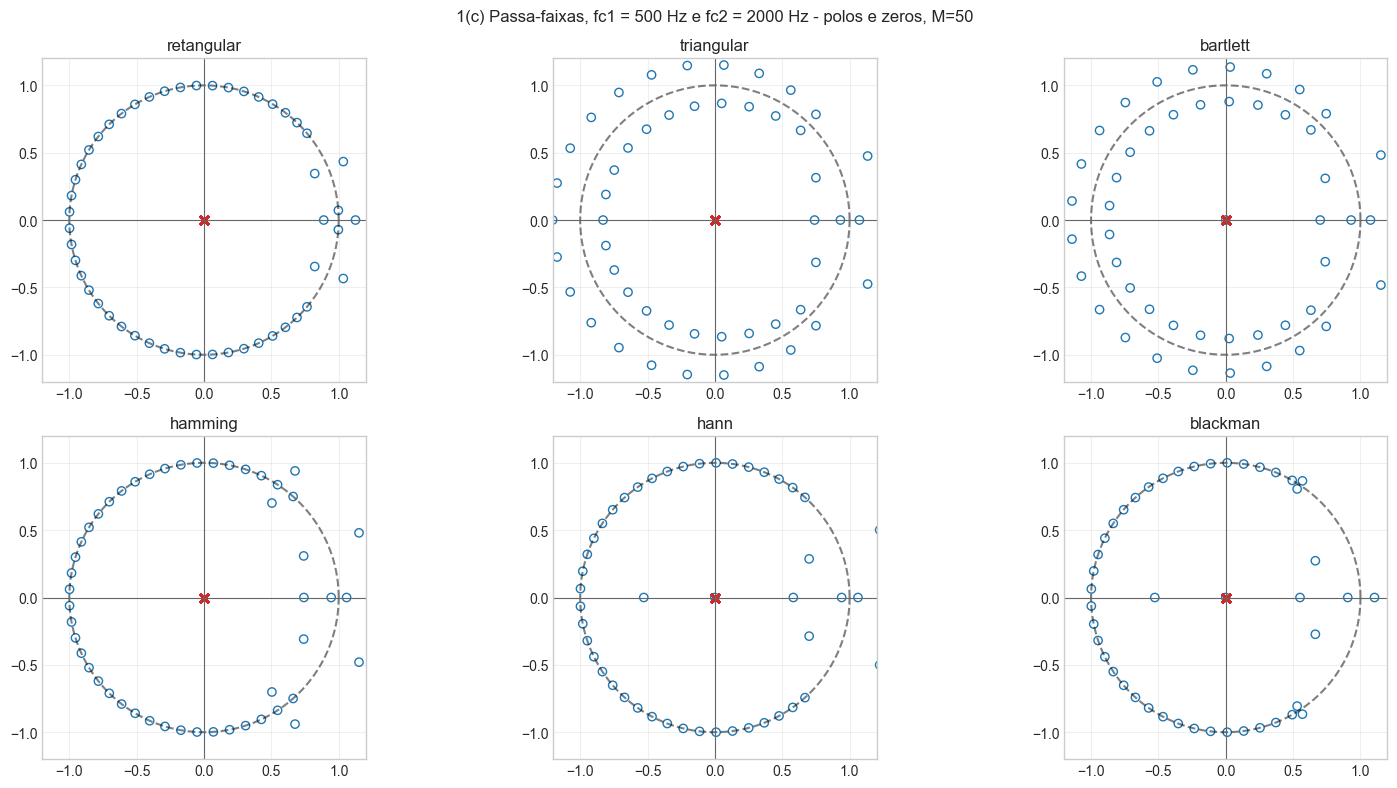

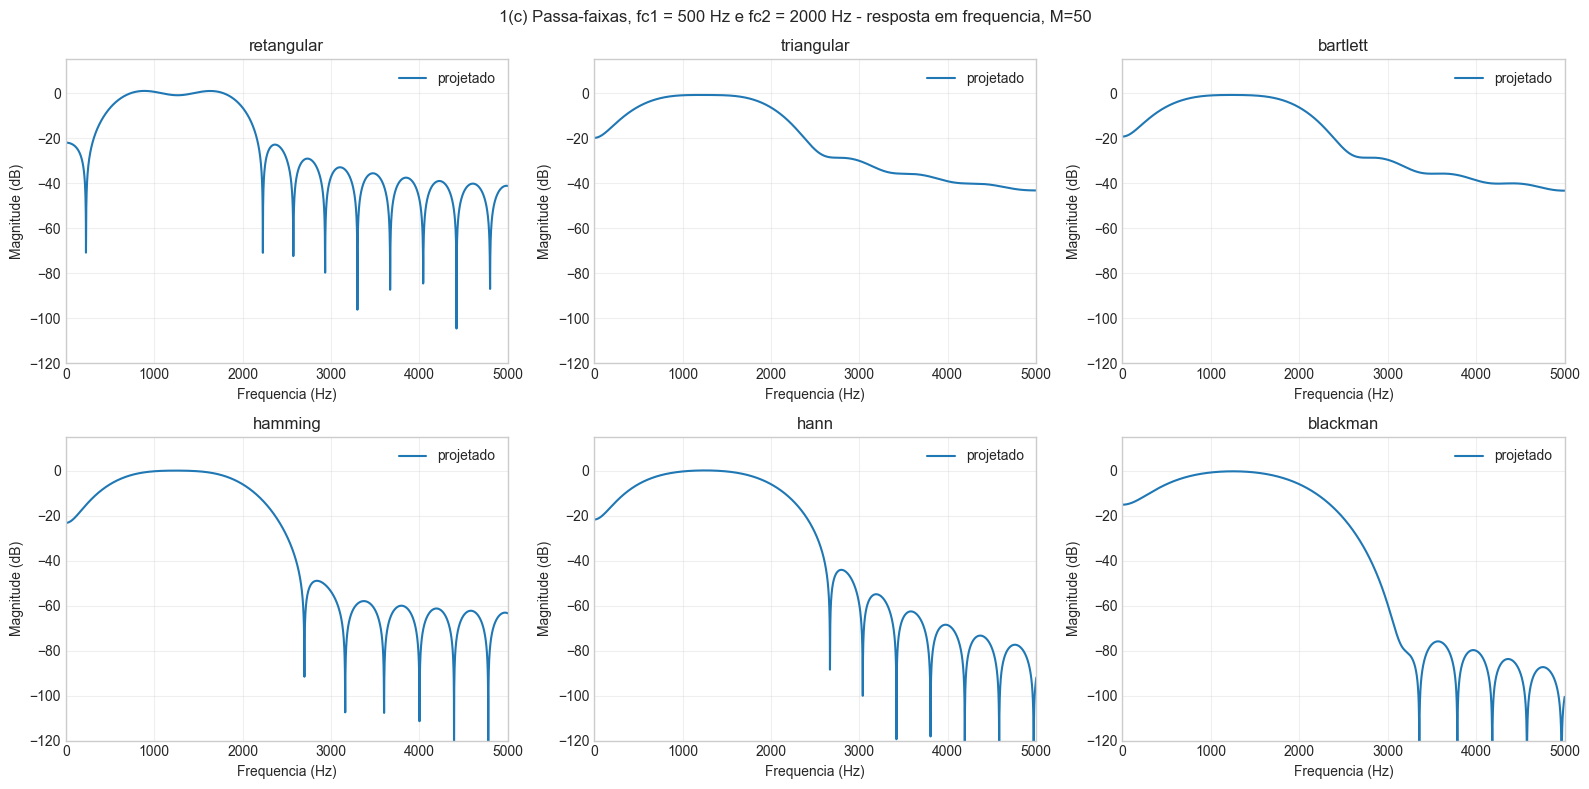

Erros de aproximacao para M=50:
Filtro     | Erro RMS | Erro max | Ganho max
-----------+----------+----------+----------
retangular | 0.087820 | 0.528677 | 1.125656 
triangular | 0.124519 | 0.517080 | 0.915438 
bartlett   | 0.127047 | 0.516888 | 0.915738 
hamming    | 0.116154 | 0.502245 | 1.002270 
hann       | 0.120585 | 0.499946 | 1.010942 
blackman   | 0.134111 | 0.500405 | 0.966520 



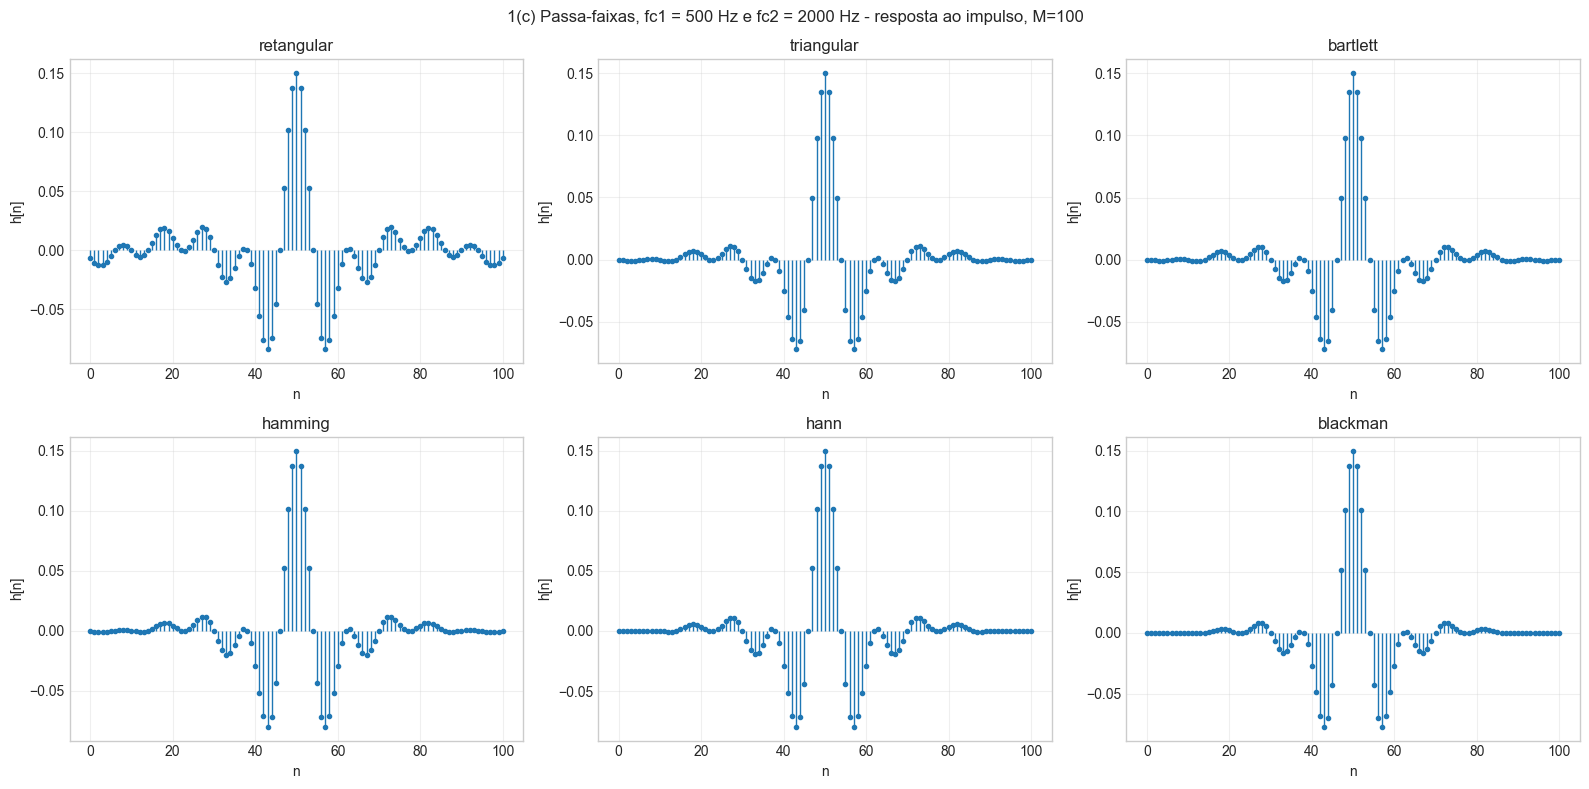

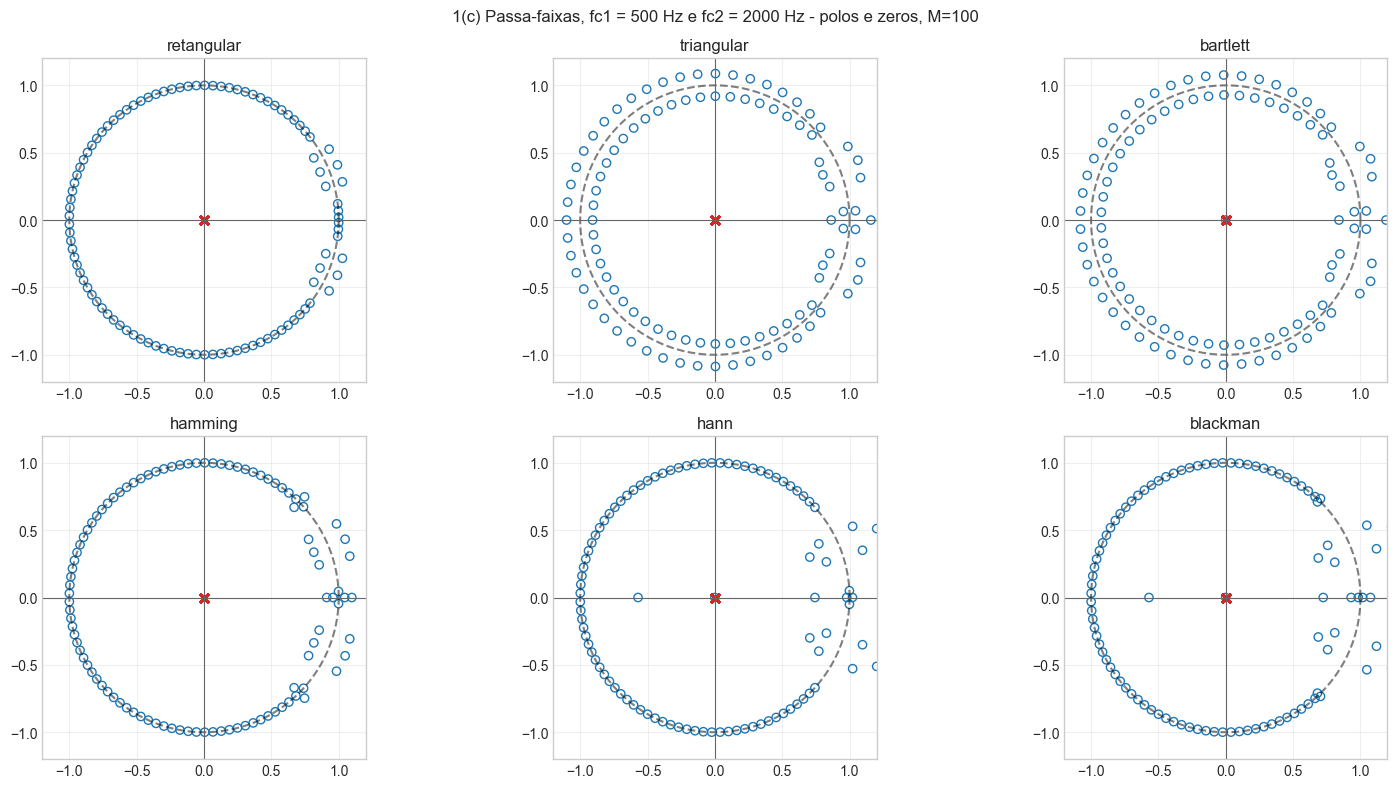

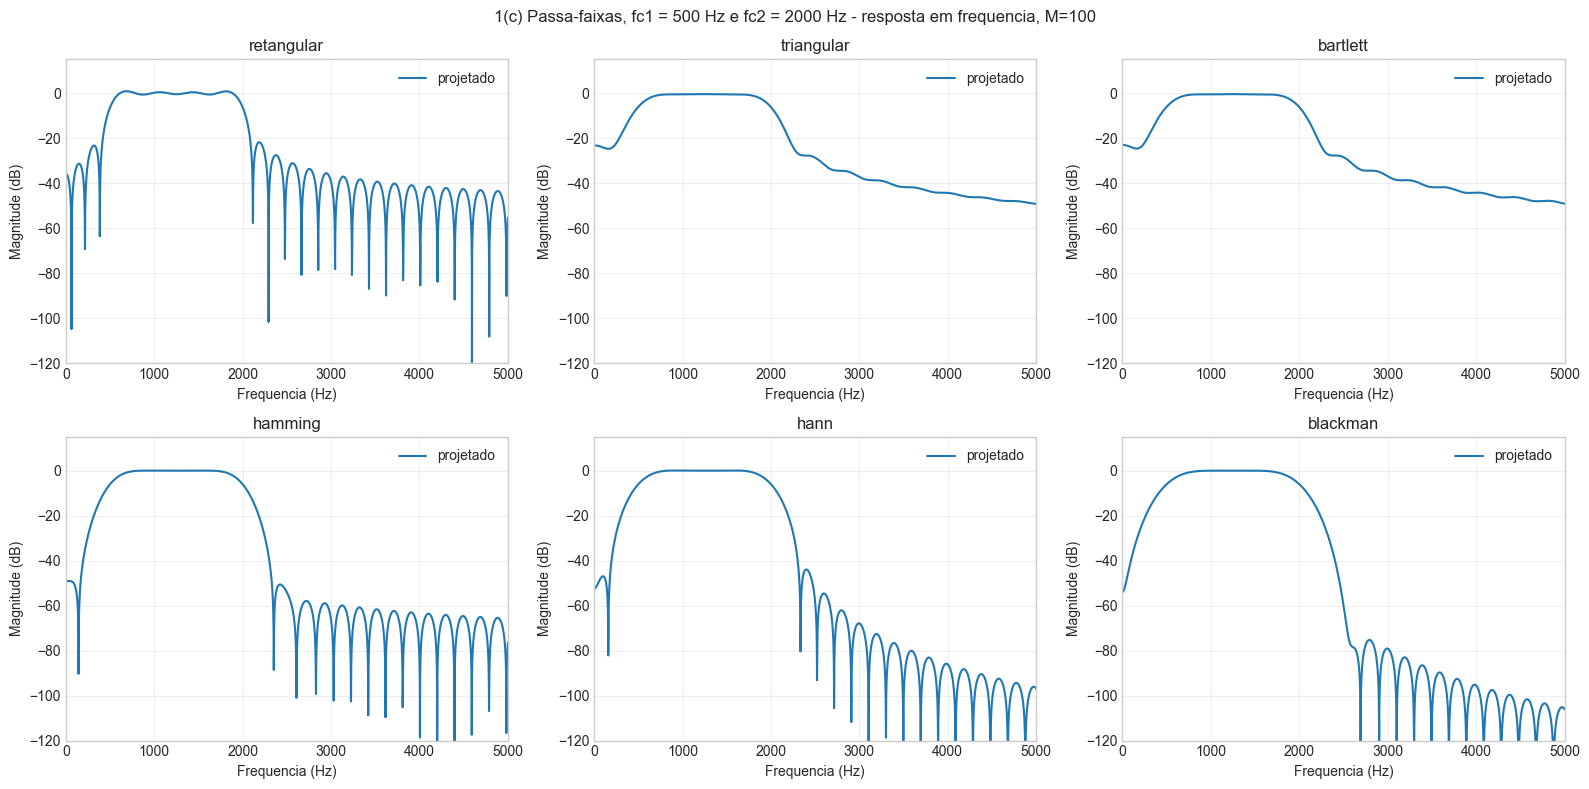

Erros de aproximacao para M=100:
Filtro     | Erro RMS | Erro max | Ganho max
-----------+----------+----------+----------
retangular | 0.061347 | 0.516927 | 1.108776 
triangular | 0.089185 | 0.507928 | 0.955661 
bartlett   | 0.090129 | 0.507940 | 0.955760 
hamming    | 0.082082 | 0.499874 | 1.003093 
hann       | 0.085307 | 0.498791 | 1.006453 
blackman   | 0.093642 | 0.498978 | 1.000262 

1(d) Rejeita-faixas, fc1 = 1000 Hz e fc2 = 2500 Hz


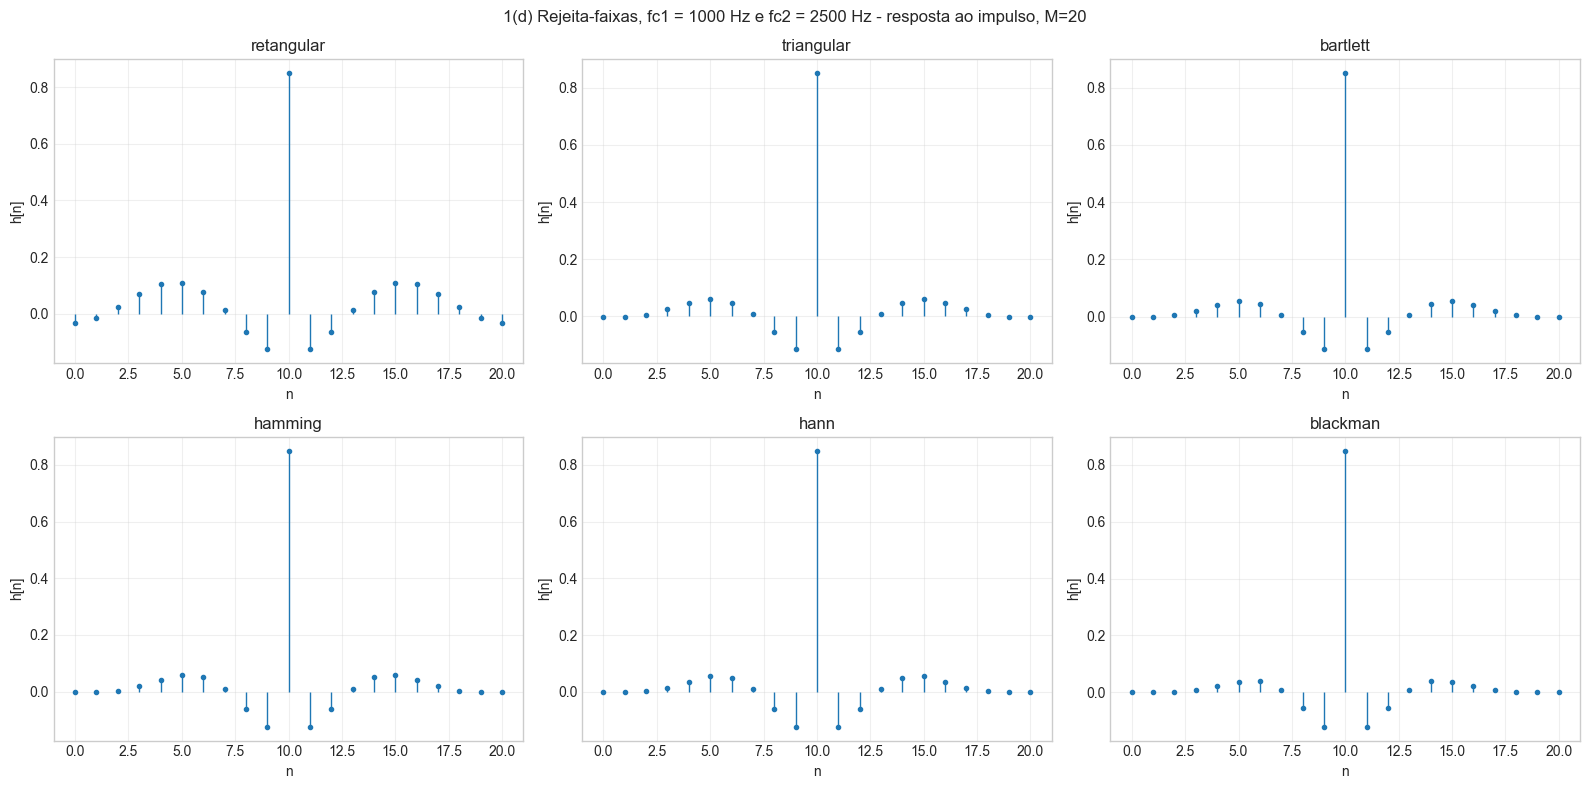

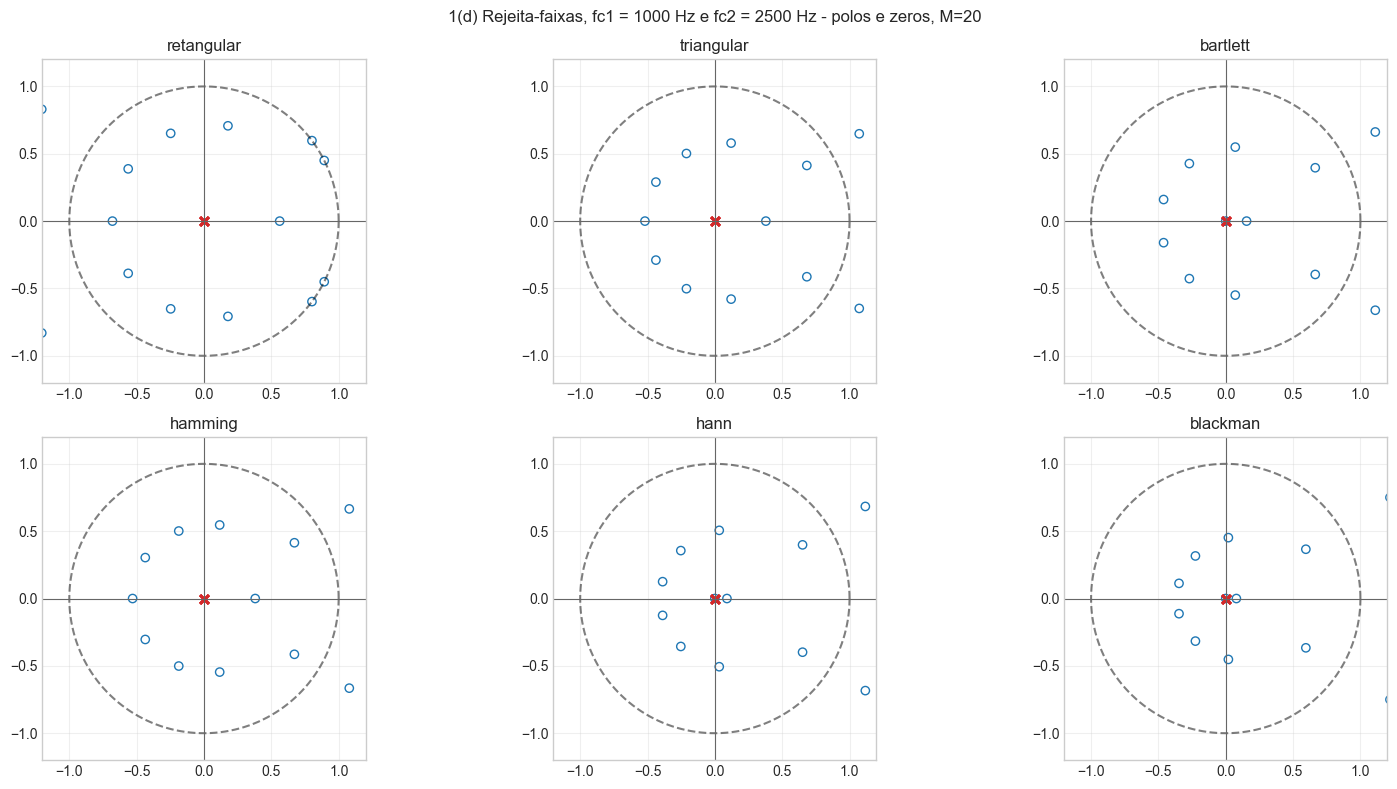

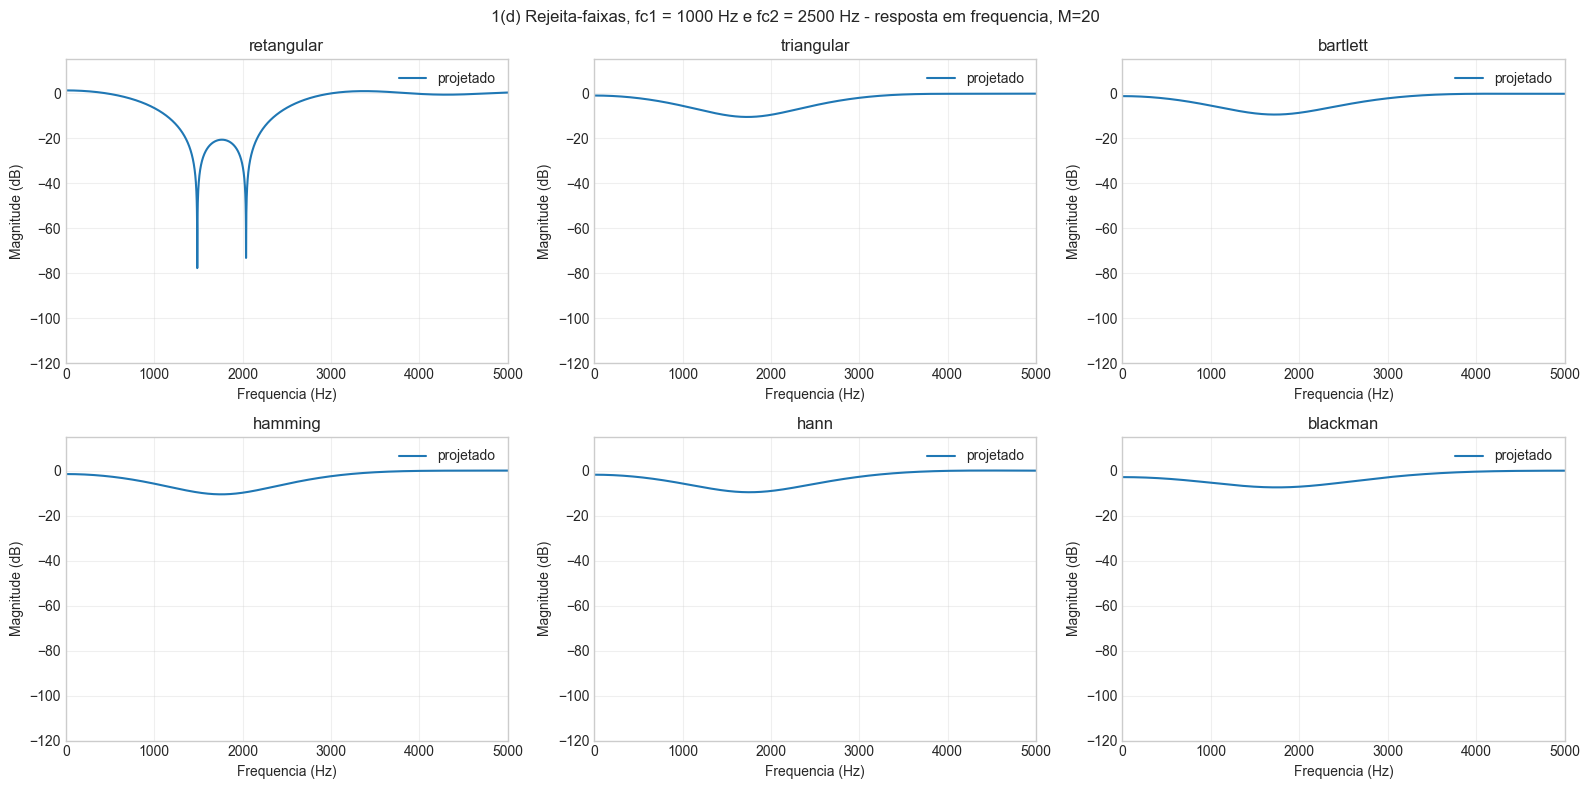

Erros de aproximacao para M=20:
Filtro     | Erro RMS | Erro max | Ganho max
-----------+----------+----------+----------
retangular | 0.130449 | 0.529836 | 1.155555 
triangular | 0.191641 | 0.540401 | 0.993931 
bartlett   | 0.202152 | 0.546960 | 0.993733 
hamming    | 0.197223 | 0.513499 | 1.003522 
hann       | 0.207046 | 0.517387 | 1.006794 
blackman   | 0.234782 | 0.549544 | 1.000195 



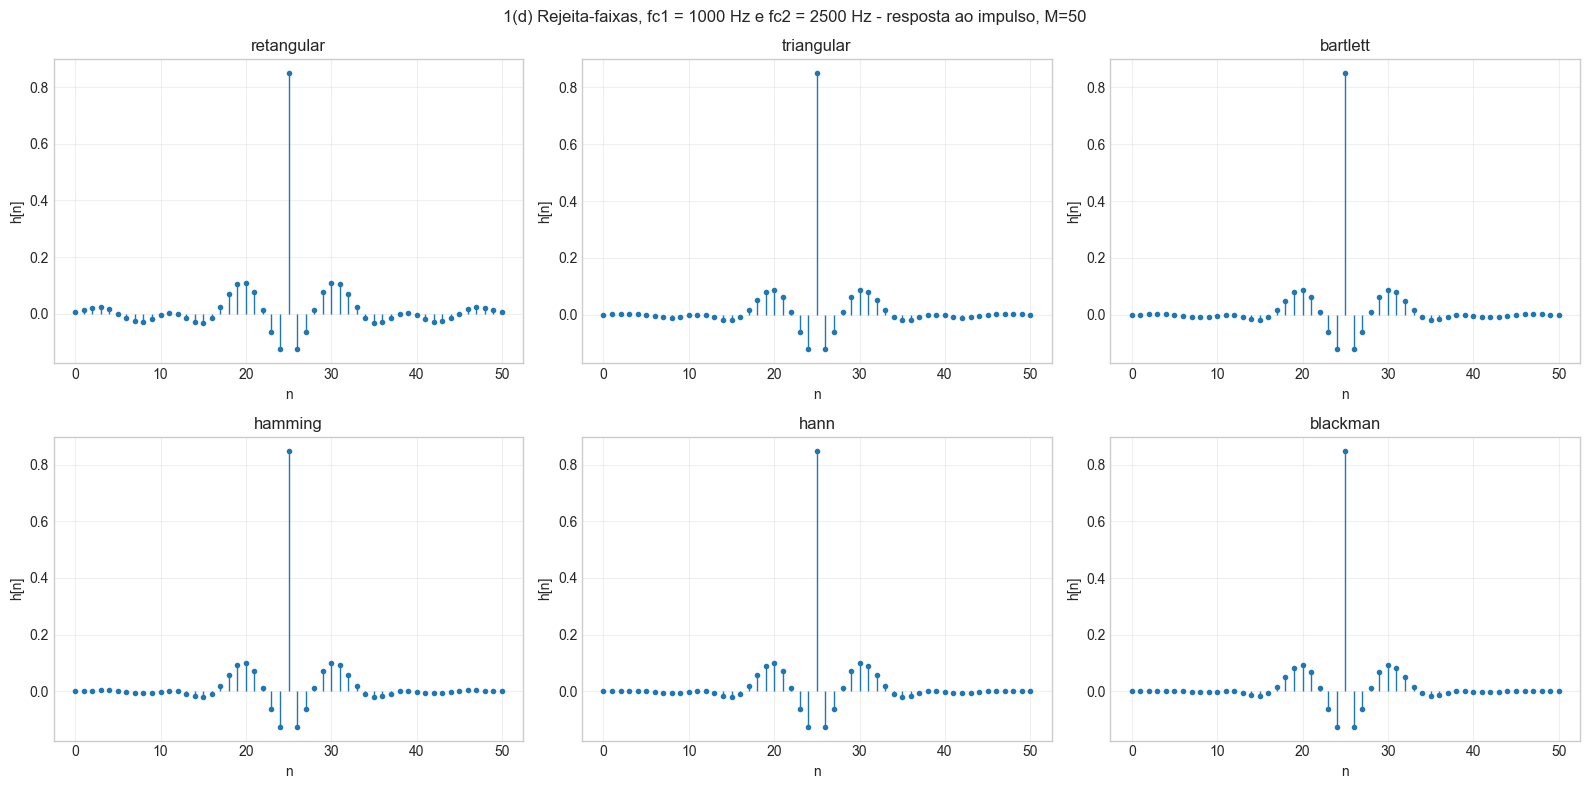

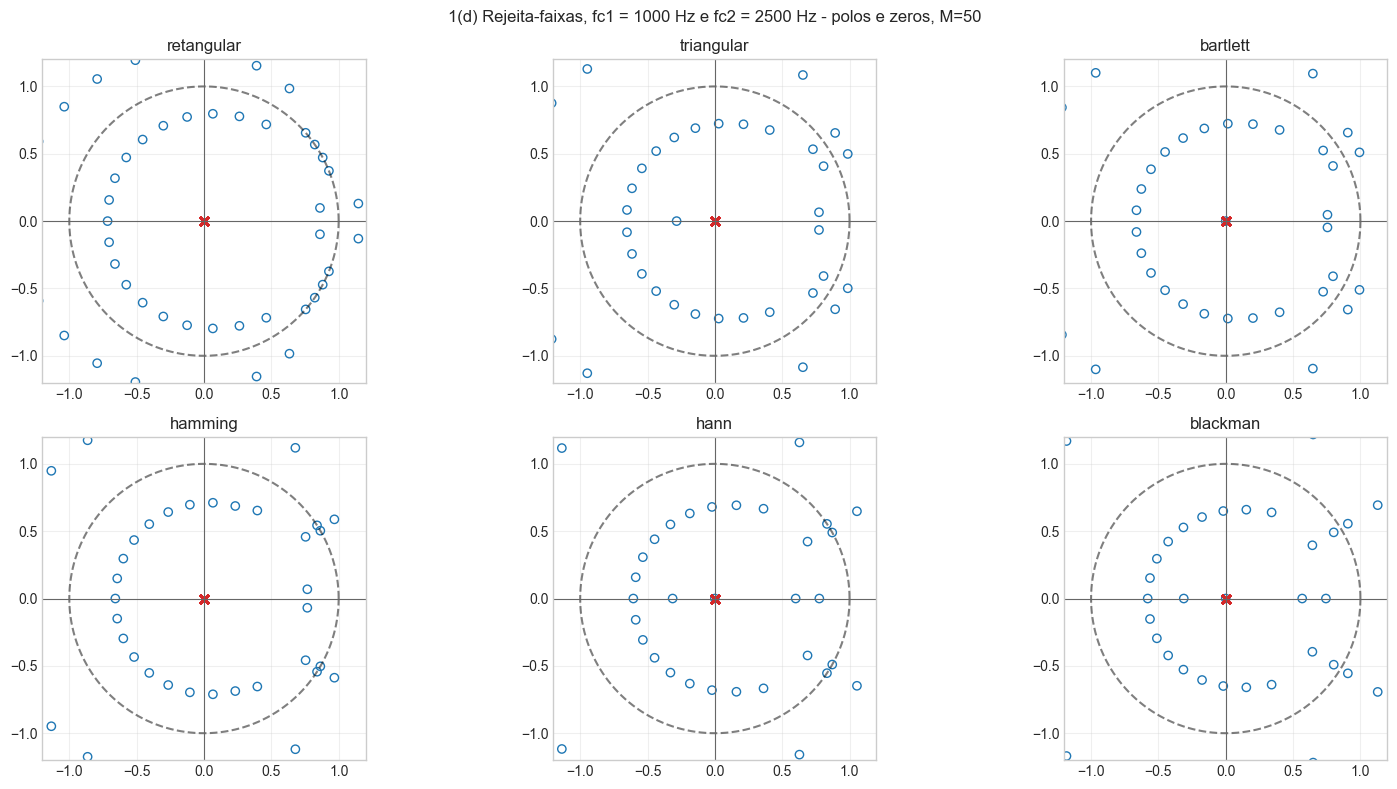

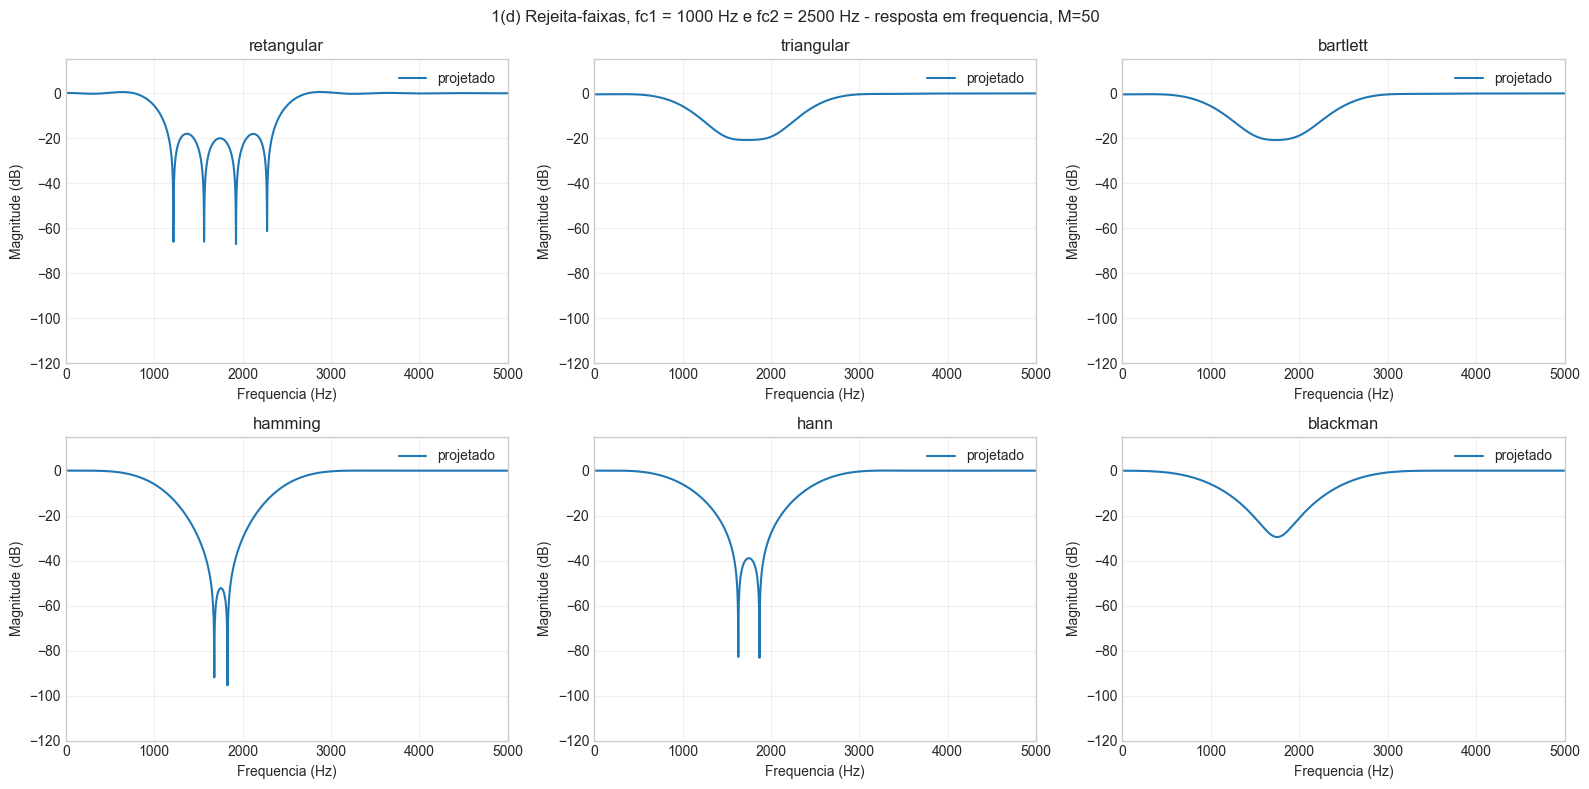

Erros de aproximacao para M=50:
Filtro     | Erro RMS | Erro max | Ganho max
-----------+----------+----------+----------
retangular | 0.086425 | 0.526793 | 1.067905 
triangular | 0.124564 | 0.520795 | 0.996915 
bartlett   | 0.127172 | 0.520555 | 0.996789 
hamming    | 0.116212 | 0.501636 | 1.003430 
hann       | 0.120833 | 0.500554 | 1.006171 
blackman   | 0.132533 | 0.499960 | 1.000147 



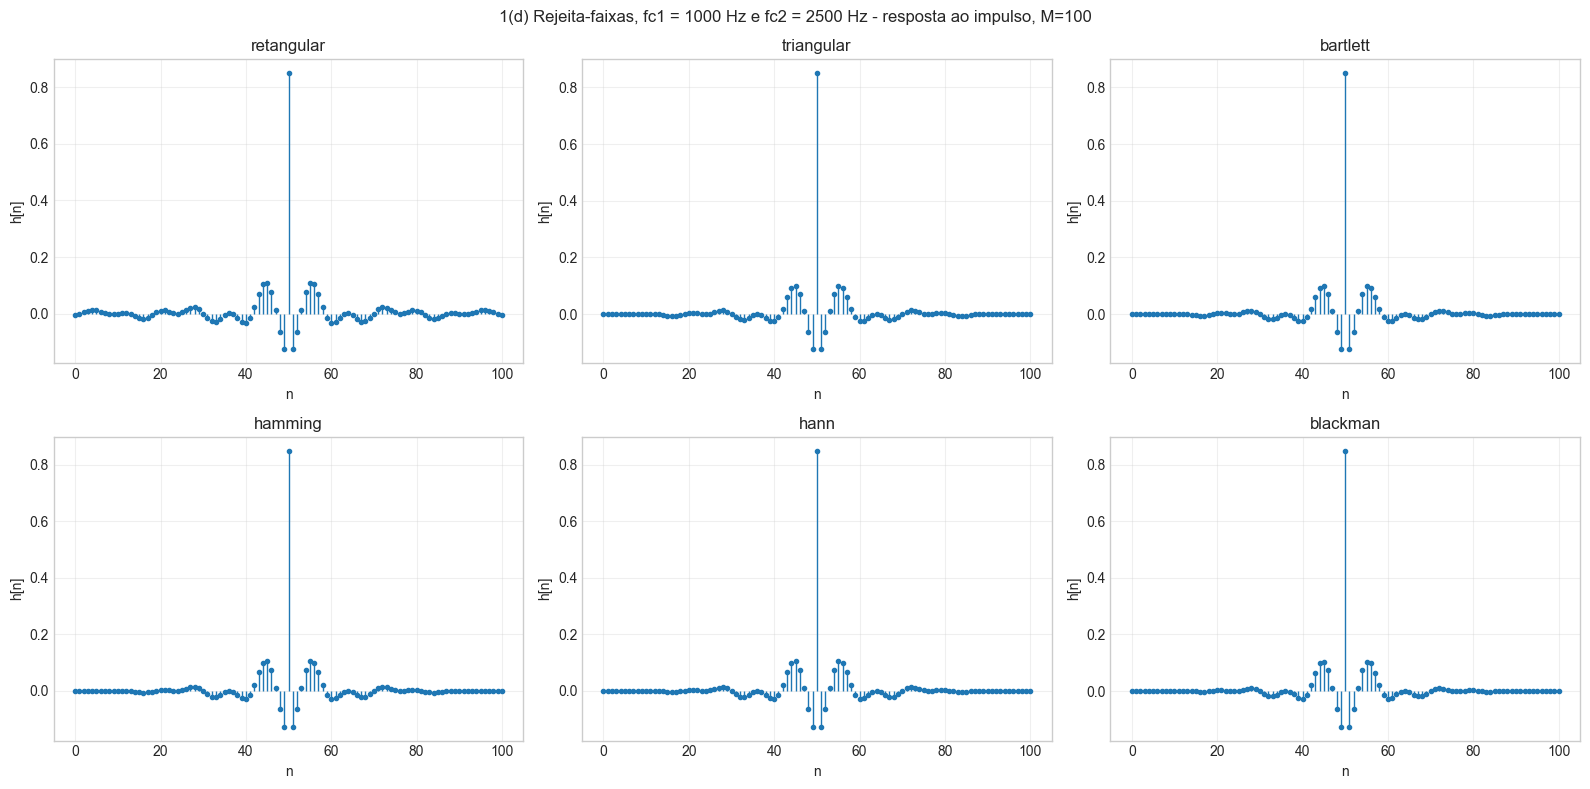

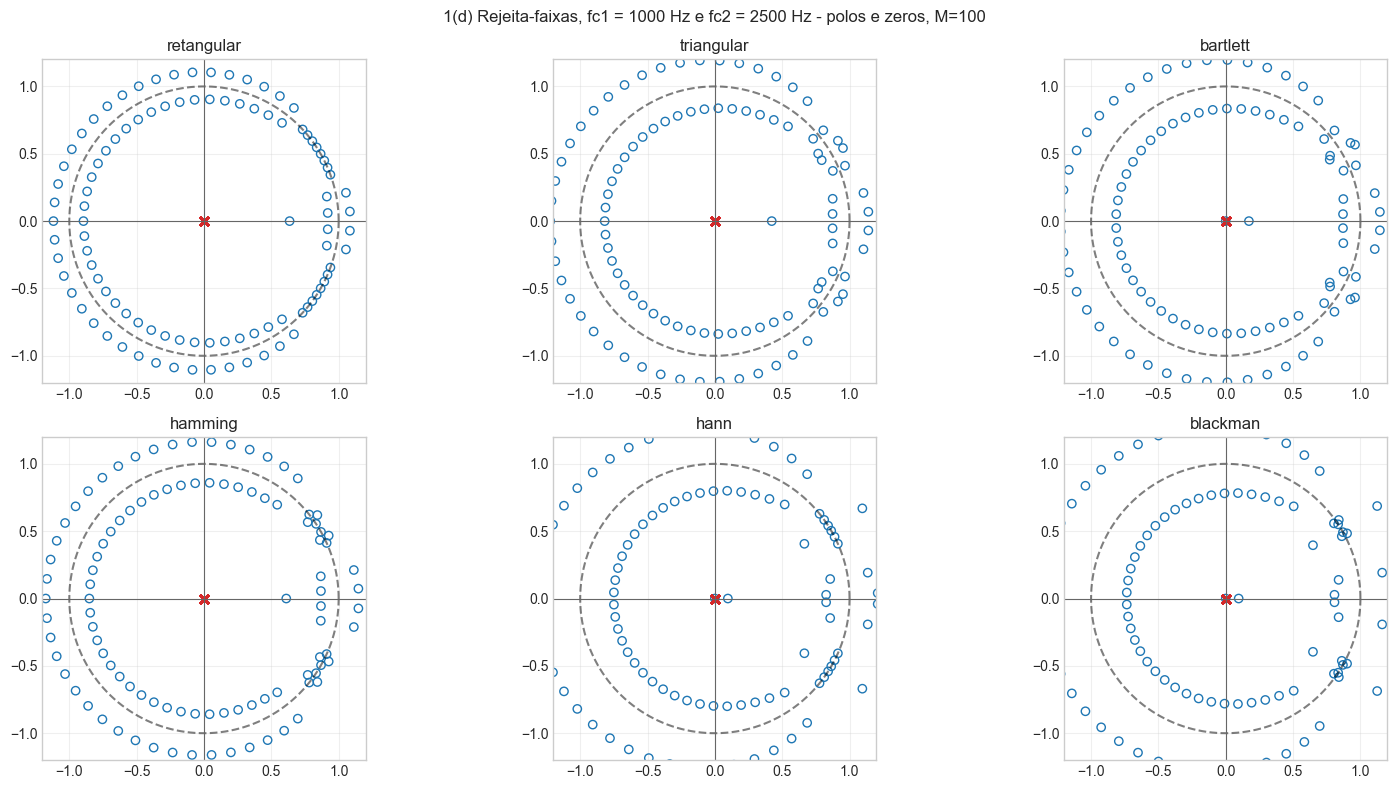

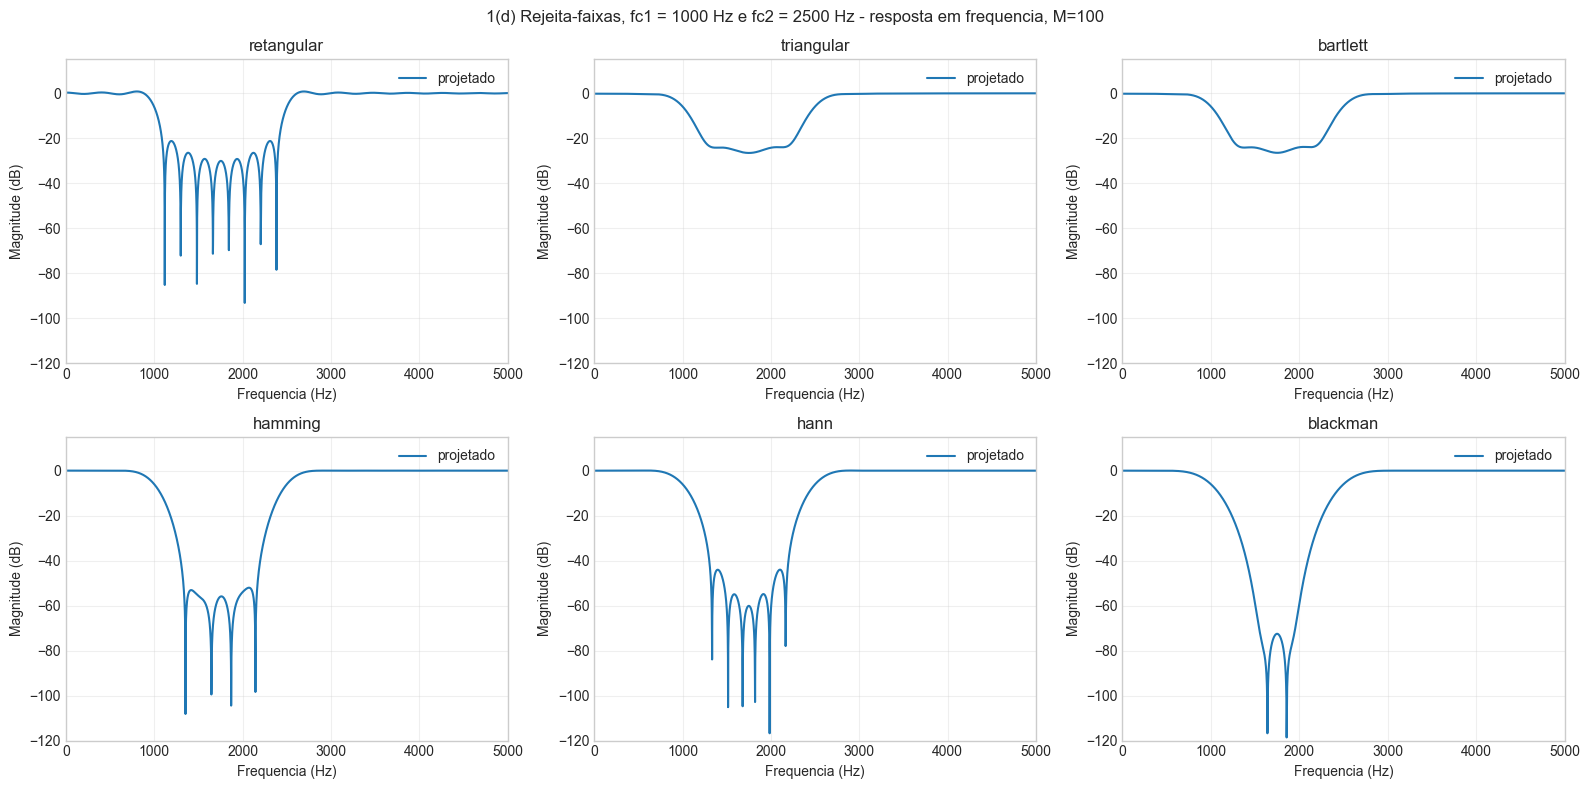

Erros de aproximacao para M=100:
Filtro     | Erro RMS | Erro max | Ganho max
-----------+----------+----------+----------
retangular | 0.062516 | 0.502853 | 1.094772 
triangular | 0.089118 | 0.510504 | 0.998471 
bartlett   | 0.090028 | 0.510787 | 0.998446 
hamming    | 0.082225 | 0.499725 | 1.001971 
hann       | 0.085315 | 0.500018 | 1.006457 
blackman   | 0.093643 | 0.500005 | 1.000244 



In [2]:
def q1_case_bank(builder, order):
    return {
        window_name: apply_window(builder(order), window_name, order)
        for window_name in WINDOWS
    }


def lp_ideal_mag(freqs_hz, fc_hz):
    freqs_hz = np.asarray(freqs_hz, dtype=float)
    return np.where(freqs_hz <= fc_hz, 1.0, 0.0)


def hp_ideal_mag(freqs_hz, fc_hz):
    freqs_hz = np.asarray(freqs_hz, dtype=float)
    return np.where(freqs_hz >= fc_hz, 1.0, 0.0)


def bp_ideal_mag(freqs_hz, fc1_hz, fc2_hz):
    freqs_hz = np.asarray(freqs_hz, dtype=float)
    return np.where((freqs_hz >= fc1_hz) & (freqs_hz <= fc2_hz), 1.0, 0.0)


def bs_ideal_mag(freqs_hz, fc1_hz, fc2_hz):
    freqs_hz = np.asarray(freqs_hz, dtype=float)
    return np.where((freqs_hz >= fc1_hz) & (freqs_hz <= fc2_hz), 0.0, 1.0)


Q1_CASES = [
    (
        '1(a) Passa-baixas, fc = 1000 Hz',
        lambda order: ideal_lowpass(1000.0, order, FS),
        lambda freqs_hz: lp_ideal_mag(freqs_hz, 1000.0),
        (0.0, 4000.0),
    ),
    (
        '1(b) Passa-altas, fc = 2000 Hz',
        lambda order: ideal_highpass(2000.0, order, FS),
        lambda freqs_hz: hp_ideal_mag(freqs_hz, 2000.0),
        (0.0, 6000.0),
    ),
    (
        '1(c) Passa-faixas, fc1 = 500 Hz e fc2 = 2000 Hz',
        lambda order: ideal_bandpass(500.0, 2000.0, order, FS),
        lambda freqs_hz: bp_ideal_mag(freqs_hz, 500.0, 2000.0),
        (0.0, 5000.0),
    ),
    (
        '1(d) Rejeita-faixas, fc1 = 1000 Hz e fc2 = 2500 Hz',
        lambda order: ideal_bandstop(1000.0, 2500.0, order, FS),
        lambda freqs_hz: bs_ideal_mag(freqs_hz, 1000.0, 2500.0),
        (0.0, 5000.0),
    ),
]


for title, builder, ideal_mag_fn, xlim in Q1_CASES:
    print('=' * 100)
    print(title)
    for order in ORDERS:
        bank = q1_case_bank(builder, order)
        plot_impulse_grid(bank, f'{title} - resposta ao impulso, M={order}', ncols=3, figsize=(16, 8))
        plot_pole_zero_grid(bank, f'{title} - polos e zeros, M={order}', ncols=3, figsize=(16, 8))
        plot_frequency_grid(
            bank,
            f'{title} - resposta em frequencia, M={order}',
            ncols=3,
            figsize=(16, 8),
            fs_hz=FS,
            xlim=xlim,
            as_db=True,
        )
        rows = summarize_error_bank(bank, ideal_mag_fn, worN=8192, fs_hz=FS)
        print(f'Erros de aproximacao para M={order}:')
        display_rows(rows, float_digits=6)
        print()


**Comentarios gerais**

- O aumento de `M` reduz o erro de aproximacao e estreita a banda de transicao em todos os casos.
- A janela retangular gera a menor largura de lobo principal, mas tambem os maiores lobos secundarios, o que aparece como maior vazamento em banda de rejeicao.
- Hamming, Hann e Blackman sacrificam transicao para reduzir ripples; entre elas, Blackman tende a oferecer a melhor rejeicao fora da banda.
- As janelas triangular e Bartlett ficam no meio do caminho: mais suaves que a retangular, mas menos seletivas que Hamming/Hann/Blackman.
- Como todos os filtros sao FIR causais, os polos aparecem empilhados na origem e os zeros se distribuem ao redor do circulo unitario de acordo com a banda rejeitada.
